[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/Quantlets/Ch_15/MFM_ch15_sem_partB/MFM_ch15_sem_partB.ipynb)

# Modelling Financial Markets — Seminar 15: LLMs and Sentiment Analysis

*Seminar notebook. Daniel Traian Pele, Antoaneta Amza (PhD candidate, antoaneta.amza@csie.ase.ro).*

- Part A: derivations: attenuation from misclassification, paired-test variance and power, the optimal temperature, Fleiss' kappa, break-even costs with standard errors.
- Part B: inference for classifiers and for sentiment signals.
- Part C: does FinBERT sentiment on headlines predict the excess return from the close of d+1 to the close of d+2, after costs?

> Quantlet `MFM_ch15_sem_partB`: student version of the Seminar 15 notebook. Solved exercises (A1, A3, A5, A7, B1, B3, B5, B7, B9) are shown with code and output; the proposed exercises (A2, A4, A6, A8, B2, B4, B6, B8, B10, B11, C1, C2, C3) are not solved here (an empty code cell where they need code).

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_15'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
import os
import io
import re
import sys
import json
import time
import zipfile
import subprocess
import urllib.request
for pkg, mod in (('pysentiment2', 'pysentiment2'), ('transformers', 'transformers')):
    try:
        __import__(mod)
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=True)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')

PHRASEBANK_URL = ('https://huggingface.co/datasets/takala/financial_phrasebank/resolve/main/data/'
                  'FinancialPhraseBank-v1.0.zip')
TWITTER_URL = 'https://huggingface.co/datasets/zeroshot/twitter-financial-news-sentiment/resolve/main/'
FNSPID_URLS = ['https://huggingface.co/datasets/Zihan1004/FNSPID/resolve/main/Stock_news/All_external.csv',
               'https://huggingface.co/datasets/Zihan1004/FNSPID/resolve/main/Stock_news/nasdaq_exteral_data.csv']
LABELS = ['negative', 'neutral', 'positive']
TW_MAP = {0: 'negative', 1: 'positive', 2: 'neutral'}          # Bearish, Bullish, Neutral
AGREE = ['50Agree', '66Agree', '75Agree', 'AllAgree']

# US stocks with FNSPID news and daily prices in the course data (Meta appears in FNSPID as FB until 2022)
TICKERS = {'AAPL': 'AAPL.US', 'MSFT': 'MSFT.US', 'AMZN': 'AMZN.US', 'NVDA': 'NVDA.US', 'TSLA': 'TSLA.US',
           'GOOGL': 'GOOGL.US', 'GOOG': 'GOOGL.US', 'META': 'META.US', 'FB': 'META.US', 'JPM': 'JPM.US',
           'BAC': 'BAC.US', 'C': 'C.US', 'GS': 'GS.US', 'MS': 'MS.US', 'WFC': 'WFC.US', 'CSCO': 'CSCO.US',
           'GME': 'GME.US', 'MSTR': 'MSTR.US', 'COIN': 'COIN.US'}
LLM_SIZES = {'0.5B': 'Qwen/Qwen2.5-0.5B-Instruct', '1.5B': 'Qwen/Qwen2.5-1.5B-Instruct',
             '3B': 'Qwen/Qwen2.5-3B-Instruct', '7B': 'Qwen/Qwen2.5-7B-Instruct', '14B': 'Qwen/Qwen2.5-14B-Instruct'}
QWEN_RELEASE = '2024-09-19'          # release of the Qwen2.5 weights
PROMPTS = {
    'P1': ('You classify the sentiment of financial news for investors. '
           'Answer with one word: positive, negative or neutral.', 'Headline: {x}\nSentiment:'),
    'P2': ('You are a financial analyst.', 'Is the following news good, bad or neutral for the stock price of the '
                                           'company it mentions? Answer with one word: positive, negative or '
                                           'neutral.\n\n{x}'),
    'P3': ('You are a helpful assistant.', 'Text: "{x}"\nWhat is the sentiment of this text? Reply positive, '
                                           'negative or neutral.'),
}


# =============================================================================
# MARKET DATA
# =============================================================================
def read_market(symbol):
    """Daily prices of one asset from the course data (local copy or the GitHub repository)."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def stock_returns(symbols, start='2009-01-01'):
    """Simple daily close-to-close returns (%) on the adjusted price, for the stocks and SPY.
    Prices are joined on common days, then returns are computed."""
    px = pd.concat({s: read_market(s)['adjusted_close'] for s in symbols}, axis=1).loc[start:]
    return 100 * px.pct_change(fill_method=None)


# =============================================================================
# LABELLED TEXTS
# =============================================================================
def load_phrasebank():
    """Financial PhraseBank v1.0: 4,846 sentences from financial news, labelled by 16 annotators.
    'agree': the highest agreement threshold reached (50%, 66%, 75%, 100%)."""
    z = zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(PHRASEBANK_URL).read()))
    sets = {}
    for lvl in AGREE:
        raw = z.read(f'FinancialPhraseBank-v1.0/Sentences_{lvl}.txt').decode('latin-1')
        sets[lvl] = [tuple(l.rsplit('@', 1)) for l in raw.splitlines() if '@' in l]
    lookup = {lvl: set(v) for lvl, v in sets.items()}
    rows = []
    for text, lab in sets['50Agree']:
        agree = max([i for i, lvl in enumerate(AGREE) if (text, lab) in lookup[lvl]] or [0])
        rows.append((text.strip(), lab.strip(), AGREE[agree]))
    d = pd.DataFrame(rows, columns=['text', 'label', 'agree'])
    return d


def load_twitter(split='valid'):
    """Twitter Financial News Sentiment: financial news headlines posted on Twitter, 2022; train / valid."""
    d = pd.read_csv(TWITTER_URL + f'sent_{split}.csv')
    d['label'] = d['label'].map(TW_MAP)
    return d


# =============================================================================
# DICTIONARIES
# =============================================================================
def load_dictionaries():
    """Word lists: Loughran-McDonald (negative, positive, uncertainty) and Harvard IV-4 (Negativ, Positiv).
    Source: the lists distributed with the pysentiment2 package."""
    try:
        import pysentiment2
    except ImportError:
        import subprocess, sys
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pysentiment2'], check=True)
        import pysentiment2
    st = os.path.join(os.path.dirname(pysentiment2.__file__), 'static')
    lm = pd.read_csv(os.path.join(st, 'LM.csv'))
    lm['Word'] = lm['Word'].astype(str).str.upper()
    gi = pd.read_csv(os.path.join(st, 'HIV-4.csv'), dtype=str)
    gi['Entry'] = gi['Entry'].astype(str).str.upper().str.replace(r'#\d+$', '', regex=True)
    return {'LM_neg': set(lm.loc[lm['Negative'] > 0, 'Word']),
            'LM_pos': set(lm.loc[lm['Positive'] > 0, 'Word']),
            'LM_unc': set(lm.loc[lm['Uncertainty'] > 0, 'Word']),
            'GI_neg': set(gi.loc[gi['Negativ'].notna(), 'Entry']),
            'GI_pos': set(gi.loc[gi['Positiv'].notna(), 'Entry'])}


TOKEN = re.compile(r"[A-Za-z][A-Za-z'\-]*")


def tokens(text):
    """Upper-case words, without digits and punctuation."""
    return [w.upper().strip("'-") for w in TOKEN.findall(str(text))]


def dict_counts(texts, pos, neg):
    """Number of positive and negative words in each text."""
    P = np.array([sum(w in pos for w in tokens(t)) for t in texts])
    N = np.array([sum(w in neg for w in tokens(t)) for t in texts])
    return P, N


def dict_tone(texts, pos, neg):
    """Tone: (P - N) / (P + N); 0 if the text has no dictionary words."""
    P, N = dict_counts(texts, pos, neg)
    return np.where(P + N > 0, (P - N) / np.maximum(P + N, 1), 0.0)


def tone_label(tone, band=0.0):
    return np.where(tone > band, 'positive', np.where(tone < -band, 'negative', 'neutral'))


def vader_compound(texts):
    """VADER compound score (Hutto & Gilbert, 2014), in [-1, 1]."""
    import nltk
    try:
        from nltk.sentiment.vader import SentimentIntensityAnalyzer
        sia = SentimentIntensityAnalyzer()
    except LookupError:
        nltk.download('vader_lexicon', quiet=True)
        from nltk.sentiment.vader import SentimentIntensityAnalyzer
        sia = SentimentIntensityAnalyzer()
    return np.array([sia.polarity_scores(str(t))['compound'] for t in texts])


# =============================================================================
# LANGUAGE MODELS
# =============================================================================
def device():
    import torch
    if torch.cuda.is_available():
        return 'cuda'
    if torch.backends.mps.is_available():
        return 'mps'
    return 'cpu'


def finbert_probs(texts, batch=64, name='ProsusAI/finbert'):
    """FinBERT probabilities (negative, neutral, positive) for each text."""
    import torch
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    tok = AutoTokenizer.from_pretrained(name)
    m = AutoModelForSequenceClassification.from_pretrained(name).to(device()).eval()
    order = [m.config.label2id[l] for l in LABELS]
    out = []
    with torch.no_grad():
        for i in range(0, len(texts), batch):
            b = tok([str(t) for t in texts[i:i + batch]], padding=True, truncation=True, max_length=96,
                    return_tensors='pt').to(m.device)
            out.append(m(**b).logits.float().softmax(-1)[:, order].cpu().numpy())
    return np.vstack(out)


def llm_load(size):
    import torch
    from transformers import AutoTokenizer, AutoModelForCausalLM
    name = LLM_SIZES[size]
    tok = AutoTokenizer.from_pretrained(name)
    tok.padding_side = 'left'
    dev = device()
    dt = torch.float16 if dev != 'cpu' else torch.float32
    m = AutoModelForCausalLM.from_pretrained(name, dtype=dt).to(dev).eval()
    return tok, m


def llm_choice_probs(tok, m, system, user_texts, choices, batch=16):
    """Zero-shot: relative probabilities of the answer words (first token of each) at the first generation
    step, after the model's chat template."""
    import torch
    ids = [tok.encode(w, add_special_tokens=False)[0] for w in choices]
    prompts = [tok.apply_chat_template([{'role': 'system', 'content': system}, {'role': 'user', 'content': u}],
                                       tokenize=False, add_generation_prompt=True) for u in user_texts]
    out = []
    with torch.no_grad():
        for i in range(0, len(prompts), batch):
            b = tok(prompts[i:i + batch], return_tensors='pt', padding=True).to(m.device)
            lg = m(**b).logits[:, -1, :][:, ids].float()
            out.append(lg.softmax(-1).cpu().numpy())
    return np.vstack(out)


def llm_sentiment(tok, m, texts, prompt='P1', batch=16):
    """Probabilities (negative, neutral, positive) from a zero-shot LLM."""
    system, user = PROMPTS[prompt]
    return llm_choice_probs(tok, m, system, [user.format(x=str(t)) for t in texts], LABELS, batch)


def embed(texts, name='sentence-transformers/all-MiniLM-L6-v2', batch=128):
    """Sentence embeddings: mean of the hidden states (mean pooling), normalised to unit length."""
    import torch
    from transformers import AutoTokenizer, AutoModel
    tok = AutoTokenizer.from_pretrained(name)
    m = AutoModel.from_pretrained(name).to(device()).eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(texts), batch):
            b = tok([str(t) for t in texts[i:i + batch]], padding=True, truncation=True, max_length=96,
                    return_tensors='pt').to(m.device)
            h = m(**b).last_hidden_state
            w = b['attention_mask'].unsqueeze(-1).float()
            e = (h * w).sum(1) / w.sum(1)
            out.append(torch.nn.functional.normalize(e, dim=1).cpu().numpy())
    return np.vstack(out)


def probs_label(P):
    """Label with the highest probability; columns are in the order of LABELS."""
    return np.array(LABELS)[np.asarray(P).argmax(1)]


def net_score(P):
    """Net sentiment score: P(positive) - P(negative), in [-1, 1]."""
    P = np.asarray(P)
    return P[:, 2] - P[:, 0]


# =============================================================================
# CLASSIFICATION METRICS
# =============================================================================
def confusion(y, yhat, labels=LABELS):
    return pd.crosstab(pd.Categorical(y, labels), pd.Categorical(yhat, labels), dropna=False,
                       rownames=['true'], colnames=['predicted'])


def macro_f1(y, yhat, labels=LABELS):
    y, yhat = np.asarray(y), np.asarray(yhat)
    f = []
    for l in labels:
        tp = np.sum((y == l) & (yhat == l))
        p = tp / max(np.sum(yhat == l), 1)
        r = tp / max(np.sum(y == l), 1)
        f.append(0 if p + r == 0 else 2 * p * r / (p + r))
    return float(np.mean(f))


def class_metrics(y, yhat, labels=LABELS):
    """Precision, recall and F1 by class."""
    y, yhat = np.asarray(y), np.asarray(yhat)
    rows = {}
    for l in labels:
        tp = np.sum((y == l) & (yhat == l))
        p = tp / max(np.sum(yhat == l), 1)
        r = tp / max(np.sum(y == l), 1)
        rows[l] = {'precision': p, 'recall': r, 'f1': 0 if p + r == 0 else 2 * p * r / (p + r),
                   'support': int(np.sum(y == l))}
    return pd.DataFrame(rows).T


def boot_ci(y, yhat, stat, B=2000, seed=0, level=0.95):
    """Bootstrap interval (i.i.d. resampling of texts) for a classification statistic."""
    rng = np.random.default_rng(seed)
    y, yhat = np.asarray(y), np.asarray(yhat)
    n = len(y)
    v = [stat(y[i], yhat[i]) for i in (rng.integers(0, n, n) for _ in range(B))]
    return tuple(np.quantile(v, [(1 - level) / 2, (1 + level) / 2]))


def acc(y, yhat):
    return float(np.mean(np.asarray(y) == np.asarray(yhat)))


def mcnemar(y, a, b):
    """Exact McNemar test: compares two classifiers on the same texts.
    n01: A wrong and B right; n10: the reverse."""
    y, a, b = map(np.asarray, (y, a, b))
    ca, cb = a == y, b == y
    n01, n10 = int(np.sum(~ca & cb)), int(np.sum(ca & ~cb))
    p = stats.binomtest(min(n01, n10), n01 + n10, 0.5).pvalue if n01 + n10 > 0 else 1.0
    return n01, n10, float(p)


def diff_ci(y, a, b, B=2000, seed=0):
    """Bootstrap interval for the accuracy difference acc(B) - acc(A), on the same texts."""
    rng = np.random.default_rng(seed)
    y, a, b = map(np.asarray, (y, a, b))
    n = len(y)
    d = [np.mean(b[i] == y[i]) - np.mean(a[i] == y[i]) for i in (rng.integers(0, n, n) for _ in range(B))]
    return tuple(np.quantile(d, [0.025, 0.975]))


# =============================================================================
# DATED NEWS AND SIGNALS
# =============================================================================
def load_fnspid(paths=None, tickers=TICKERS):
    """FNSPID headlines (both parts: external sources and Nasdaq) for the stocks in TICKERS:
    date (UTC), headline, ticker. Repeated headlines (same headline, stock and day) are kept once."""
    out = []
    for src in (paths or FNSPID_URLS):
        for ch in pd.read_csv(src, usecols=['Date', 'Article_title', 'Stock_symbol'], chunksize=500_000, dtype=str,
                              on_bad_lines='skip'):
            out.append(ch[ch['Stock_symbol'].isin(tickers)])
    d = pd.concat(out).dropna()
    d['ts'] = pd.to_datetime(d['Date'], utc=True, errors='coerce')
    d = d.dropna(subset=['ts'])
    d['ticker'] = d['Stock_symbol'].map(lambda s: TICKERS[s].replace('.US', ''))
    d['title'] = d['Article_title'].str.strip()
    d = d.assign(dd=d['ts'].dt.date).drop_duplicates(['ticker', 'title', 'dd'])
    return d[['ts', 'ticker', 'title']].reset_index(drop=True)


def assign_trading_day(ts, days):
    """FNSPID gives only the publication date (the time is 00:00 UTC for almost all headlines): a headline dated d
    is assigned to the first trading day >= d. The time of day is unknown, so the news may appear
    after the close of day d."""
    d0 = ts.dt.tz_convert('UTC').dt.tz_localize(None).dt.normalize()
    days = pd.DatetimeIndex(days).sort_values()
    pos = days.searchsorted(d0.values)
    ok = pos < len(days)
    out = pd.Series(pd.NaT, index=ts.index)
    out[ok] = days[pos[ok]]
    return out


def daily_panel(S, rets):
    """S: mean scores by (day, stock), indexed (day, ticker). Adds the excess return over SPY
    on the news day (r0), on the next two days (r1, r2) and on days -5..+5 (event study:
    rm5..rm1, r0, r1, r2, rp3..rp5). Without a time stamp, r1 may still contain the reaction to the news; the first
    safely tradable return is r2 (from the close of the next day)."""
    ex = rets.drop(columns='SPY').sub(rets['SPY'], axis=0)
    P = S.copy()
    for k in range(-5, 6):
        name = {0: 'r0', 1: 'r1', 2: 'r2'}.get(k, f'rp{k}' if k > 0 else f'rm{-k}')
        sh = ex.shift(-k).stack()
        sh.index.names = ['day', 'ticker']
        P = P.join(sh.rename(name), how='left')
    return P.dropna(subset=['r0', 'r1', 'r2'])


def cluster_ols(y, x, groups):
    """OLS y = a + b x with ordinary and day-clustered standard errors (Petersen, 2009)."""
    X = np.column_stack([np.ones(len(x)), x])
    y = np.asarray(y, float)
    XtX = np.linalg.inv(X.T @ X)
    b = XtX @ X.T @ y
    e = y - X @ b
    n, k = X.shape
    V_ols = XtX * (e @ e) / (n - k)
    idx_g = pd.Series(np.arange(n)).groupby(np.asarray(groups)).apply(list)
    meat = sum(np.outer(X[i].T @ e[i], X[i].T @ e[i]) for i in idx_g)
    G = len(idx_g)
    V_cl = XtX @ meat @ XtX * G / (G - 1) * (n - 1) / (n - k)
    return {'b': b[1], 'a': b[0], 'se_ols': np.sqrt(V_ols[1, 1]), 'se_cl': np.sqrt(V_cl[1, 1]),
            't_ols': b[1] / np.sqrt(V_ols[1, 1]), 't_cl': b[1] / np.sqrt(V_cl[1, 1]),
            'r2': 1 - (e @ e) / np.sum((y - y.mean()) ** 2), 'n': n, 'G': G}


def nw_t(x, lags=None):
    """Mean and t statistic with the Newey-West (HAC) variance."""
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    n = len(x)
    L = lags if lags is not None else int(np.floor(4 * (n / 100) ** (2 / 9)))
    u = x - x.mean()
    v = u @ u / n
    for l in range(1, L + 1):
        v += 2 * (1 - l / (L + 1)) * (u[l:] @ u[:-l]) / n
    return x.mean(), x.mean() / np.sqrt(v / n)


def block_boot_mean(x, B=2000, block=10, seed=0):
    """Moving-block bootstrap interval for the mean of a daily series."""
    rng = np.random.default_rng(seed)
    x = np.asarray(x, float)
    n = len(x)
    nb = int(np.ceil(n / block))
    v = []
    for _ in range(B):
        st = rng.integers(0, n - block + 1, nb)
        v.append(np.concatenate([x[s:s + block] for s in st])[:n].mean())
    return tuple(np.quantile(v, [0.025, 0.975]))


def signal_portfolio(P, col, days, cost_bp=0.0, band=0.0, ret='r2'):
    """Daily strategy: for each stock with news (|score| > band) take the position sign(score), hedged with SPY,
    equal weights; the gain is the excess return in column ret (default r2: the position opens at the
    close of the day after the news, when the news is surely public). Days without positions return 0.
    Cost: cost_bp basis points per trade (stock and SPY, at entry and at exit: 4 x cost)."""
    q = P[P[col].abs() > band]
    lag = {'r0': 0, 'r1': 1, 'r2': 2}[ret]
    pos_day = pd.DatetimeIndex(days)
    idx = pos_day.get_indexer(q.index.get_level_values('day'))
    ok = (idx >= 0) & (idx + lag < len(pos_day))
    q = q[ok]
    earn_day = pos_day[idx[ok] + lag]
    x = pd.Series(np.sign(q[col].values) * q[ret].values, index=earn_day)
    grp = x.groupby(level=0)
    R = pd.DataFrame({'gross': grp.mean(), 'k': grp.size()}).reindex(pos_day).fillna(0.0)
    R['net'] = R['gross'] - np.where(R['k'] > 0, 4 * cost_bp / 100, 0.0)
    return R


def sharpe(x, ppy=252):
    x = np.asarray(x, float)
    return float(np.sqrt(ppy) * x.mean() / x.std(ddof=1))

In [ ]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Colours
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Crimson = '#DC3545'
Teal = '#17A2B8'
Magenta = '#D63384'
Brown = '#795548'
Gray = '#7F7F7F'          # reference lines only
LightGray = '#DADADA'     # bands only

LAB_COL = {'negative': IDAred, 'neutral': Amber, 'positive': Forest}
METHODS = ['GI', 'VADER', 'LM', 'TF-IDF + LR', 'MiniLM + LR', 'FinBERT', 'Qwen 0.5B', 'Qwen 1.5B', 'Qwen 3B',
           'Qwen 7B', 'Qwen 14B']
M_COL = {'GI': Brown, 'VADER': Amber, 'LM': Orange, 'TF-IDF + LR': Teal, 'MiniLM + LR': Magenta,
         'FinBERT': MainBlue, 'Qwen 0.5B': '#F4A6A6', 'Qwen 1.5B': '#E86A6A', 'Qwen 3B': Crimson,
         'Qwen 7B': IDAred, 'Qwen 14B': '#7A0000'}
SIZES_B = {'0.5B': 0.5, '1.5B': 1.5, '3B': 3.0, '7B': 7.0, '14B': 14.0}
SCORE_LBL = {'lm': 'Loughran-McDonald tone', 'finbert': 'FinBERT', 'qwen': 'Qwen2.5-7B'}
SCORE_COL = {'lm': Orange, 'finbert': MainBlue, 'qwen': IDAred}
EVENT_COLS = ['rm5', 'rm4', 'rm3', 'rm2', 'rm1', 'r0', 'r1', 'r2', 'rp3', 'rp4', 'rp5']
PERIODS = (('2010', '2015'), ('2016', '2019'), ('2020', '2021'), ('2022', '2023'))


RES = {}
FC_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/Quantlets/Ch_15/'
FC_DIR = next((d for d in ('.', '..', 'Quantlets/Ch_15', '../Quantlets/Ch_15', '../../Quantlets/Ch_15')
               if os.path.exists(os.path.join(d, 'ch15_twitter_scores.csv'))), None)


def save_fig(name):
    """Save the figure as transparent PDF and PNG in the current folder."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def load_csv(name, **kw):
    """A saved score table of the chapter, local copy or the repository."""
    path = os.path.join(FC_DIR, name) if FC_DIR else FC_RAW + name
    return pd.read_csv(path, **kw)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles, labels, ncol=3, y=0.0):
    """One legend for the whole figure, below the panels."""
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def predictions(d):
    """Label predicted by each method (one column per method in the score tables)."""
    v = d['vader'].values
    out = {'GI': tone_label(d['GI_tone'].values), 'LM': tone_label(d['LM_tone'].values),
           'VADER': np.where(v >= 0.05, 'positive', np.where(v <= -0.05, 'negative', 'neutral')),
           'TF-IDF + LR': probs_label(d[[f'tfidf_{l}' for l in LABELS]].values),
           'MiniLM + LR': probs_label(d[[f'emb_{l}' for l in LABELS]].values),
           'FinBERT': probs_label(d[[f'finbert_{l}' for l in LABELS]].values)}
    for s in SIZES_B:
        out[f'Qwen {s}'] = probs_label(d[[f'qwen{s}_{l}' for l in LABELS]].values)
    return out


def jsonable(o):
    if isinstance(o, dict):
        return {str(k): jsonable(v) for k, v in o.items() if not isinstance(v, pd.DataFrame)}
    if isinstance(o, (list, tuple)):
        return [jsonable(v) for v in o]
    if isinstance(o, (np.floating, np.integer)):
        return o.item()
    return o

LAB_COL = {'negative': '#CD0000', 'neutral': '#B5853F', 'positive': '#2E7D32'}
METHODS = ['GI', 'VADER', 'LM', 'TF-IDF + LR', 'MiniLM + LR', 'FinBERT', 'Qwen 0.5B', 'Qwen 1.5B', 'Qwen 3B', 'Qwen 7B', 'Qwen 14B']
M_COL = {'GI': '#795548', 'VADER': '#B5853F', 'LM': '#E67E22', 'TF-IDF + LR': '#17A2B8', 'MiniLM + LR': '#D63384', 'FinBERT': '#1A3A6E', 'Qwen 0.5B': '#F4A6A6', 'Qwen 1.5B': '#E86A6A', 'Qwen 3B': '#DC3545', 'Qwen 7B': '#CD0000', 'Qwen 14B': '#7A0000'}
SIZES_B = {'0.5B': 0.5, '1.5B': 1.5, '3B': 3.0, '7B': 7.0, '14B': 14.0}
SCORE_LBL = {'lm': 'Loughran-McDonald tone', 'finbert': 'FinBERT', 'qwen': 'Qwen2.5-7B'}
SCORE_COL = {'lm': '#E67E22', 'finbert': '#1A3A6E', 'qwen': '#CD0000'}
EVENT_COLS = ['rm5', 'rm4', 'rm3', 'rm2', 'rm1', 'r0', 'r1', 'r2', 'rp3', 'rp4', 'rp5']
PERIODS = (('2010', '2015'), ('2016', '2019'), ('2020', '2021'), ('2022', '2023'))


def save_fig(name):
    """Show the figure; with SAVE_TO_DRIVE = True also save it (PDF and PNG) in OUT_DIR."""
    if globals().get('SAVE_TO_DRIVE'):
        for ext in ('pdf', 'png'):
            plt.savefig(os.path.join(OUT_DIR, f'{name}.{ext}'), bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()

In [ ]:
HERE = OUT_DIR if globals().get('SAVE_TO_DRIVE') else '.'   # recomputed tables go here
SEED = 15
MONTHS = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']


def tick(msg, t0):
    print(f'   {msg}: {time.time() - t0:.0f}s', flush=True)


def dict_cols(d, texts, D):
    for k in ('LM', 'GI'):
        P, N = dict_counts(texts, D[k + '_pos'], D[k + '_neg'])
        d[f'{k}_pos'], d[f'{k}_neg'] = P, N
        d[f'{k}_tone'] = np.where(P + N > 0, (P - N) / np.maximum(P + N, 1), 0.0)
    d['vader'] = vader_compound(texts)


def texts_block():
    t0 = time.time()
    pb, tw, tr = load_phrasebank(), load_twitter('valid'), load_twitter('train')
    D = load_dictionaries()
    out = {'pb': pb[['label', 'agree']].copy(), 'tw': tw[['label']].copy()}
    src = {'pb': pb['text'].tolist(), 'tw': tw['text'].tolist()}
    for k in out:
        dict_cols(out[k], src[k], D)
    tick('dictionaries', t0)
    for k in out:
        P = finbert_probs(src[k])
        for j, l in enumerate(LABELS):
            out[k][f'finbert_{l}'] = P[:, j]
    tick('FinBERT', t0)
    for size in LLM_SIZES:
        tok, m = llm_load(size)
        for k in out:
            prompts = ['P1', 'P2', 'P3'] if (k == 'tw' and size in ('1.5B', '7B', '14B')) else ['P1']
            for pr in prompts:
                t1 = time.time()
                P = llm_sentiment(tok, m, src[k], pr)
                tag = f'qwen{size}' + ('' if pr == 'P1' else f'_{pr}')
                for j, l in enumerate(LABELS):
                    out[k][f'{tag}_{l}'] = P[:, j]
                out[k].attrs[f'time_{tag}'] = (time.time() - t1) / len(src[k])
        del m
        try:
            import torch
            torch.mps.empty_cache()
        except Exception:
            pass
        tick(f'Qwen {size}', t0)
    # embeddings + logistic regression, trained on the Twitter training set
    from sklearn.linear_model import LogisticRegression
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.decomposition import PCA
    Etr, Etw, Epb = embed(tr['text'].tolist()), embed(src['tw']), embed(src['pb'])
    clf = LogisticRegression(C=4.0, max_iter=3000).fit(Etr, tr['label'])
    for k, E in (('tw', Etw), ('pb', Epb)):
        P = clf.predict_proba(E)[:, [list(clf.classes_).index(l) for l in LABELS]]
        for j, l in enumerate(LABELS):
            out[k][f'emb_{l}'] = P[:, j]
    tf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True).fit(tr['text'])
    clf2 = LogisticRegression(C=8.0, max_iter=3000).fit(tf.transform(tr['text']), tr['label'])
    for k in out:
        P = clf2.predict_proba(tf.transform(src[k]))[:, [list(clf2.classes_).index(l) for l in LABELS]]
        for j, l in enumerate(LABELS):
            out[k][f'tfidf_{l}'] = P[:, j]
    pc = PCA(2, random_state=SEED).fit(Etr)
    xy = pc.transform(Etw)
    out['tw']['pc1'], out['tw']['pc2'] = xy[:, 0], xy[:, 1]
    tick('embeddings', t0)
    # learning curve: how many labels are needed?
    rng = np.random.default_rng(SEED)
    rows = []
    for n in (100, 200, 400, 800, 1600, 3200, 6400, len(tr)):
        for rep in range(10 if n < len(tr) else 1):
            idx = rng.choice(len(tr), n, replace=False) if n < len(tr) else np.arange(len(tr))
            y = tr['label'].values[idx]
            if len(set(y)) < 3:
                continue
            a = LogisticRegression(C=4.0, max_iter=3000).fit(Etr[idx], y).predict(Etw)
            tfn = TfidfVectorizer(ngram_range=(1, 2), min_df=1, sublinear_tf=True).fit(tr['text'].values[idx])
            b = LogisticRegression(C=8.0, max_iter=3000).fit(tfn.transform(tr['text'].values[idx]), y).predict(
                tfn.transform(src['tw']))
            rows.append({'n': n, 'rep': rep, 'emb_acc': acc(tw['label'], a), 'emb_f1': macro_f1(tw['label'], a),
                         'tfidf_acc': acc(tw['label'], b), 'tfidf_f1': macro_f1(tw['label'], b)})
    pd.DataFrame(rows).to_csv(os.path.join(HERE, 'ch15_learning_curve.csv'), index=False)
    for k, name in (('pb', 'ch15_phrasebank_scores.csv'), ('tw', 'ch15_twitter_scores.csv')):
        out[k].round(6).to_csv(os.path.join(HERE, name), index_label='id')
    times = {**out['tw'].attrs}
    pd.Series(times).to_csv(os.path.join(HERE, 'ch15_llm_time.csv'), header=['sec_per_text'])
    tick('texts done', t0)


def memory_block(sizes=('1.5B', '7B', '14B')):
    """Monthly direction of the S&P 500 (2000-2026) and daily direction of Apple, asked with no context."""
    t0 = time.time()
    px = read_market('GSPC.INDX')['close']
    mon = px.resample('ME').last()
    mret = 100 * mon.pct_change().dropna().loc['2000-01':'2026-08']
    aapl = read_market('AAPL.US')['adjusted_close']
    dret = 100 * aapl.pct_change().dropna()
    rng = np.random.default_rng(SEED)
    pre = dret.loc['2010-01-01':'2023-12-31']
    post = dret.loc['2024-10-01':]
    days = pd.concat([pre.iloc[np.sort(rng.choice(len(pre), 500, replace=False))], post])
    dm = pd.DataFrame({'ret': mret})
    dd = pd.DataFrame({'ret': days})
    sys_m = 'You are a financial historian. Answer with one word: rise or fall.'
    q_m = [f'Did the S&P 500 index rise or fall during {MONTHS[d.month - 1]} {d.year}?' for d in dm.index]
    sys_d = 'You are a financial historian. Answer with one word: higher or lower.'
    q_d = [f'Did Apple (AAPL) stock close higher or lower on {d.strftime("%A")}, {MONTHS[d.month - 1]} {d.day}, '
           f'{d.year} than on the previous trading day?' for d in dd.index]
    for size in sizes:
        tok, m = llm_load(size)
        dm[f'qwen{size}'] = llm_choice_probs(tok, m, sys_m, q_m, ['rise', 'fall'])[:, 0]
        dd[f'qwen{size}'] = llm_choice_probs(tok, m, sys_d, q_d, ['higher', 'lower'])[:, 0]
        del m
        tick(f'memory {size}', t0)
    dm.round(6).to_csv(os.path.join(HERE, 'ch15_memory_monthly.csv'), index_label='month')
    dd.round(6).to_csv(os.path.join(HERE, 'ch15_memory_daily.csv'), index_label='date')


def news_block(paths=None, llm='7B', batch=64):
    """Scores for each headline, then means by (trading day, stock)."""
    t0 = time.time()
    news = load_fnspid(paths)
    tick(f'FNSPID {len(news)} headlines', t0)
    rets = stock_returns(sorted(set(TICKERS.values())) + ['SPY.US'], start='2009-01-01')
    rets.columns = [c.replace('.US', '') for c in rets.columns]
    news['day'] = assign_trading_day(news['ts'], rets.index)
    news = news.dropna(subset=['day'])
    news = news[news['day'] >= '2009-06-01']
    D = load_dictionaries()
    P, N = dict_counts(news['title'].tolist(), D['LM_pos'], D['LM_neg'])
    news['lm'] = np.where(P + N > 0, (P - N) / np.maximum(P + N, 1), 0.0)
    news['lm_hit'] = (P + N > 0).astype(int)
    F = finbert_probs(news['title'].tolist(), batch=256)
    news['finbert'] = net_score(F)
    news['finbert_lab'] = F.argmax(1) - 1
    tick('FinBERT', t0)
    tok, m = llm_load(llm)
    Q = llm_sentiment(tok, m, news['title'].tolist(), 'P1', batch=batch)
    news['qwen'] = net_score(Q)
    tick(f'Qwen {llm}', t0)
    grp = news.groupby(['day', 'ticker'])
    daily = grp[['finbert', 'lm', 'qwen']].mean()
    daily['n'] = grp.size()
    daily['lm_hit'] = grp['lm_hit'].mean()
    daily.round(6).to_csv(os.path.join(HERE, 'ch15_news_daily.csv'))
    by_year = news.groupby([news['day'].dt.year, 'ticker']).size().unstack(fill_value=0)
    by_year.to_csv(os.path.join(HERE, 'ch15_news_counts.csv'))
    hour = news['ts'].dt.tz_convert('UTC').dt.hour.value_counts().reindex(range(24), fill_value=0)
    exact = ((news['ts'].dt.hour == 0) & (news['ts'].dt.minute == 0) & (news['ts'].dt.second == 0)).mean()
    pd.DataFrame({'n': hour, 'share_midnight': exact}).to_csv(os.path.join(HERE, 'ch15_news_hours.csv'))
    # scores of the individual headlines (without text) for the comparison of methods
    news[['day', 'ticker', 'finbert', 'finbert_lab', 'lm', 'lm_hit', 'qwen']].round(5).to_csv(
        os.path.join(HERE, 'ch15_news_headlines.csv.gz'), index=False, compression='gzip')
    tick('news done', t0)

In [ ]:
# True: recompute all scores (downloads FinBERT, MiniLM, Qwen2.5 0.5B-14B and the FNSPID
# headlines; hours without a GPU); False: use the scores saved with Chapter 15.
RECOMPUTE = False
if RECOMPUTE:
    texts_block()
    memory_block()
    news_block()
    FC_DIR = HERE

In [ ]:
# Evaluation functions from the lecture
def eval_texts():
    pb, tw = load_csv('ch15_phrasebank_scores.csv'), load_csv('ch15_twitter_scores.csv')
    R = {'n_pb': len(pb), 'n_tw': len(tw), 'n_pb_all': int((pb['agree'] == 'AllAgree').sum())}
    for name, d in (('pb', pb), ('tw', tw)):
        y = d['label'].values
        pr = predictions(d)
        R[name] = {}
        for m, yh in pr.items():
            lo, hi = boot_ci(y, yh, acc, B=1000)
            R[name][m] = {'acc': acc(y, yh), 'lo': lo, 'hi': hi, 'f1': macro_f1(y, yh)}
        R[name]['share'] = d['label'].value_counts(normalize=True).to_dict()
        R[name]['always_neutral_f1'] = macro_f1(y, np.full(len(y), 'neutral'))
    # annotator agreement (PhraseBank)
    pr = predictions(pb)
    R['agree'] = {lvl: {m: acc(pb['label'][pb['agree'] == lvl], pr[m][pb['agree'] == lvl])
                        for m in ('LM', 'FinBERT', 'Qwen 7B', 'Qwen 14B')} for lvl in AGREE}
    R['agree_n'] = pb['agree'].value_counts().to_dict()
    # paired tests (Twitter)
    y = tw['label'].values
    pt = predictions(tw)
    R['pairs'] = {}
    for a, b in (('LM', 'FinBERT'), ('FinBERT', 'Qwen 7B'), ('FinBERT', 'Qwen 14B'), ('Qwen 1.5B', 'Qwen 7B'),
                 ('FinBERT', 'MiniLM + LR')):
        n01, n10, p = mcnemar(y, pt[a], pt[b])
        lo, hi = diff_ci(y, pt[a], pt[b], B=1000)
        R['pairs'][f'{a}|{b}'] = {'n01': n01, 'n10': n10, 'p': p, 'diff': acc(y, pt[b]) - acc(y, pt[a]),
                                  'lo': lo, 'hi': hi}
    # prompt wording
    R['prompts'] = {}
    for s in ('1.5B', '7B', '14B'):
        labs = {p: probs_label(tw[[f'qwen{s}{"" if p == "P1" else "_" + p}_{l}' for l in LABELS]].values)
                for p in ('P1', 'P2', 'P3')}
        R['prompts'][s] = {p: {'acc': acc(y, v), 'f1': macro_f1(y, v)} for p, v in labs.items()}
        R['prompts'][s]['agree_all'] = float(np.mean((labs['P1'] == labs['P2']) & (labs['P1'] == labs['P3'])))
        R['prompts'][s]['share_neutral'] = {p: float(np.mean(v == 'neutral')) for p, v in labs.items()}
    t = load_csv('ch15_llm_time.csv', index_col=0)['sec_per_text']
    R['time'] = {k.replace('time_qwen', ''): float(v) for k, v in t.items() if '_' not in k.replace('time_qwen', '')}
    lc = load_csv('ch15_learning_curve.csv')
    R['lc'] = lc.groupby('n')[['emb_acc', 'tfidf_acc', 'emb_f1', 'tfidf_f1']].mean().to_dict('index')
    for name, d in (('pb', pb), ('tw', tw)):
        for m in ('LM', 'FinBERT', 'Qwen 7B'):
            R[name][m]['cm'] = confusion(d['label'], predictions(d)[m]).values.tolist()
    RES['texts'] = R
    return pb, tw


def stats_auc(a, b):
    from scipy.stats import mannwhitneyu
    if len(a) == 0 or len(b) == 0:
        return np.nan
    return mannwhitneyu(a, b).statistic / (len(a) * len(b))


def auc(p, up):
    p, up = np.asarray(p), np.asarray(up, bool)
    return float(stats_auc(p[up], p[~up]))


def boot_auc(p, up, B=2000, seed=0):
    rng = np.random.default_rng(seed)
    p, up = np.asarray(p), np.asarray(up, bool)
    v = []
    for _ in range(B):
        i = rng.integers(0, len(p), len(p))
        if up[i].all() or (~up[i]).all():
            continue
        v.append(stats_auc(p[i][up[i]], p[i][~up[i]]))
    return tuple(np.quantile(v, [0.025, 0.975]))


def news_panel():
    daily = load_csv('ch15_news_daily.csv', parse_dates=['day']).set_index(['day', 'ticker'])
    syms = sorted(set(TICKERS.values()))
    rets = stock_returns(syms + ['SPY.US'], start='2009-01-01')
    rets.columns = [c.replace('.US', '') for c in rets.columns]
    rets = rets.loc[:'2023-12-31']
    P = daily_panel(daily, rets)
    for c in SCORE_LBL:
        P[f'z_{c}'] = (P[c] - P[c].mean()) / P[c].std()
    return P, rets


def event_groups(x):
    """Event-study groups: the most negative and the most positive tercile of the daily score. If the two
    cut-offs coincide (the LM tone is exactly 0 on almost half of the stock-days), the disjoint groups are
    score < cut-off and score > cut-off, and days equal to the cut-off are excluded."""
    q1, q2 = x.quantile([1 / 3, 2 / 3])
    if q1 >= q2:
        return x < q1, x > q2
    return x <= q1, x >= q2


def eval_news(P, rets):
    cnt = load_csv('ch15_news_counts.csv', index_col=0)
    hl = load_csv('ch15_news_headlines.csv.gz', usecols=['finbert', 'lm', 'lm_hit', 'qwen', 'finbert_lab'])
    R = {'n_headlines': int(cnt.values.sum()), 'n_tickers': int((cnt.sum() > 0).sum()),
         'n_obs': len(P), 'n_days': int(P.index.get_level_values('day').nunique()),
         'first': str(P.index.get_level_values('day').min().date()),
         'last': str(P.index.get_level_values('day').max().date()),
         'per_year': cnt.sum(1).to_dict(), 'per_ticker': cnt.sum().sort_values(ascending=False).to_dict(),
         'mean_n': float(P['n'].mean()), 'lm_hit': float(hl['lm_hit'].mean()),
         'fb_share': (hl['finbert_lab'].value_counts(normalize=True).sort_index()).tolist(),
         'corr': hl[['lm', 'finbert', 'qwen']].corr().round(3).to_dict(),
         'corr_daily': P[['lm', 'finbert', 'qwen']].corr().round(3).to_dict()}
    R['reg'] = {}
    groups = P.index.get_level_values('day')
    for c in SCORE_LBL:
        for y in ('r0', 'r1', 'r2'):
            R['reg'][f'{c}|{y}'] = {k: float(v) for k, v in cluster_ols(P[y].values, P[f'z_{c}'].values,
                                                                           groups).items()}
    # event study: terciles of the FinBERT score
    cols = EVENT_COLS
    R['event'] = {}
    for c in ('finbert', 'qwen', 'lm'):
        neg, pos = event_groups(P[c])
        ev = {}
        for grp, sel in (('neg', neg), ('pos', pos)):
            X = P.loc[sel, cols].groupby(level='day').mean()
            car = X.fillna(0).cumsum(axis=1)
            ev[grp] = {'car': car.mean().tolist(), 'se': (car.std() / np.sqrt(len(car))).tolist(), 'n_days': len(X),
                       'n': int(sel.sum())}
        R['event'][c] = ev
    # the strategy
    days = rets.index[(rets.index >= P.index.get_level_values('day').min())]
    R['strat'] = {}
    for c in SCORE_LBL:
        St = signal_portfolio(P, c, days, cost_bp=5, ret='r2')
        S1 = signal_portfolio(P, c, days, ret='r1')
        m1, t1 = nw_t(S1['gross'])
        mu, t = nw_t(St['gross'])
        lo, hi = block_boot_mean(St['gross'].values)
        mun, tn = nw_t(St['net'])
        active = St['k'] > 0
        R['strat'][c] = {'mean_bp': 1e2 * mu, 't': t, 'lo_bp': 1e2 * lo, 'hi_bp': 1e2 * hi,
                         'sr': sharpe(St['gross']), 'sr_net': sharpe(St['net']), 't_net': tn,
                         'mean_net_bp': 1e2 * mun, 'active': float(active.mean()),
                         'mean_active_bp': 1e2 * St.loc[active, 'gross'].mean(),
                         'breakeven_bp': 1e2 * St.loc[active, 'gross'].mean() / 4,
                         'r1_mean_bp': 1e2 * m1, 'r1_t': t1, 'r1_sr': sharpe(S1['gross']),
                         'years': {}}
        for a, b in PERIODS:
            x = St.loc[a:b, 'gross']
            m_, t_ = nw_t(x)
            R['strat'][c]['years'][f'{a}-{b}'] = {'mean_bp': 1e2 * m_, 't': t_}
        R['strat'][c]['cum'] = St[['gross', 'net']]
    RES['news'] = R
    return P


pb, tw = eval_texts()
P, rets = news_panel()
eval_news(P, rets)
D = load_dictionaries()
S = {}

## Part A — derivations with numbers

In [ ]:
# Seminar functions
def dict_example(text, D):
    w = tokens(text)
    out = {}
    for k in ('LM', 'GI'):
        pos = [x for x in w if x in D[k + '_pos']]
        neg = [x for x in w if x in D[k + '_neg']]
        P, N = len(pos), len(neg)
        out[k] = {'pos': pos, 'neg': neg, 'P': P, 'N': N, 'tone': (P - N) / (P + N) if P + N else 0.0}
    out['n_words'] = len(w)
    return out


def part_a():
    """A1-A2: tone under two dictionaries; A3-A4: metrics from the confusion matrix; A5-A6: probabilities and
    the majority class; A7-A8: the cost at which the strategy stops earning."""
    pb = load_phrasebank()
    D = load_dictionaries()
    # real PhraseBank sentences (100% agreement) on which the two dictionaries give different signs
    allag = pb[pb['agree'] == 'AllAgree'].copy()
    allag['len'] = allag['text'].str.len()
    lm = dict_tone(allag['text'], D['LM_pos'], D['LM_neg'])
    gi = dict_tone(allag['text'], D['GI_pos'], D['GI_neg'])
    c1 = allag[(allag['label'] == 'positive') & (lm > 0) & (gi < 0)].sort_values('len')
    c2 = allag[(allag['label'] == 'neutral') & (lm == 0) & (gi < 0)].sort_values('len')
    for key, text in (('A1', c1['text'].iloc[0]), ('A2', c2['text'].iloc[0])):
        r = dict_example(text, D)
        r['label'] = pb.loc[pb['text'] == text, 'label'].iloc[0]
        r['text'] = text
        S[key] = r
    tw = load_csv('ch15_twitter_scores.csv')
    pr = predictions(tw)
    for key, m in (('A3', 'FinBERT'), ('A4', 'LM')):
        cm = confusion(tw['label'], pr[m])
        cmx = class_metrics(tw['label'], pr[m])
        S[key] = {'cm': cm.values.tolist(), 'acc': acc(tw['label'], pr[m]), 'f1': macro_f1(tw['label'], pr[m]),
                  'metrics': cmx.to_dict('index')}
    # A5: Qwen2.5-7B probabilities for one headline; temperature
    i = int(np.argmin(np.abs(tw['qwen7B_negative'] - 0.62)))
    p = tw.loc[i, ['qwen7B_negative', 'qwen7B_neutral', 'qwen7B_positive']].values.astype(float)
    logit = np.log(np.maximum(p, 1e-12))
    logit = logit - logit.max()
    T = 2.0
    pT = np.exp(logit / T) / np.exp(logit / T).sum()
    S['A5'] = {'id': i, 'label': tw.loc[i, 'label'], 'p': p.tolist(), 'logit': logit.tolist(), 'T': T,
               'pT': pT.tolist(), 'net': float(p[2] - p[0])}
    n = tw['label'].value_counts()
    S['A6'] = {'n': n.to_dict(), 'N': int(n.sum()), 'acc_neutral': float(n['neutral'] / n.sum()),
               'f1_neutral_class': float(2 * (n['neutral'] / n.sum()) / (1 + n['neutral'] / n.sum())),
               'macro_f1': macro_f1(tw['label'], np.full(len(tw), 'neutral'))}


part_a()

In [ ]:
# Pairs of classifiers and the strategies, needed by Part A
def b_pairs(a, b, data='tw'):
    d = load_csv('ch15_twitter_scores.csv' if data == 'tw' else 'ch15_phrasebank_scores.csv')
    y = d['label'].values
    pr = predictions(d)
    n01, n10, p = mcnemar(y, pr[a], pr[b])
    lo, hi = diff_ci(y, pr[a], pr[b])
    return {'acc_a': acc(y, pr[a]), 'acc_b': acc(y, pr[b]), 'diff': acc(y, pr[b]) - acc(y, pr[a]),
            'lo': lo, 'hi': hi, 'n01': n01, 'n10': n10, 'p': p,
            'ci_a': boot_ci(y, pr[a], acc), 'ci_b': boot_ci(y, pr[b], acc)}


def part_a_inference(R):
    """A1-A8 (derivations): attenuation from misclassification (Aigner, 1973), variance and power of the McNemar test,
    Fleiss' kappa and one Dawid-Skene E step on a small table, the first-order condition for the temperature,
    the standard error of the break-even cost (delta method)."""
    from scipy import stats as st
    out = {}
    # A1-A2: the "negative news" dummy (row/column 0 of the Twitter confusion matrix)
    for key in ('A3', 'A4'):
        cm = np.array(S[key]['cm'], float)
        n = cm.sum()
        pi = cm[0].sum() / n
        p = cm[:, 0].sum() / n
        a1 = (cm[0, 1] + cm[0, 2]) / cm[0].sum()
        a0 = (cm[1, 0] + cm[2, 0]) / (cm[1].sum() + cm[2].sum())
        lam = pi * (1 - pi) * (1 - a0 - a1) / (p * (1 - p))
        out['att_' + key] = {'n': n, 'pi': pi, 'p': p, 'a0': a0, 'a1': a1, 'lam': lam, 'inv': 1 / lam,
                             'n_tp': cm[0, 0], 'n_neg': cm[0].sum(), 'n_predneg': cm[:, 0].sum(),
                             'n_fp': cm[1, 0] + cm[2, 0], 'n_nonneg': cm[1].sum() + cm[2].sum()}
    # A3-A4: paired accuracy difference, multinomial variance, exact McNemar, power
    for key in ('B1', 'B2'):
        b = S[key]
        n = int(np.array(S['A3']['cm']).sum())       # headlines of the Twitter validation set
        n01, n10 = b['n01'], b['n10']
        d = (n01 - n10) / n
        q = (n01 + n10) / n
        se = np.sqrt((q - d ** 2) / n)
        pz = 2 * st.norm.sf(abs(d) / se)
        pex = 2 * st.binom.cdf(min(n01, n10), n01 + n10, 0.5)
        zc = st.norm.ppf(0.975)
        power = st.norm.cdf(abs(d) * np.sqrt(n) / np.sqrt(q - d ** 2) - zc)
        n80 = (zc + st.norm.ppf(0.8)) ** 2 * (q - d ** 2) / d ** 2
        out['mc_' + key] = {'n': n, 'n01': n01, 'n10': n10, 'd': d, 'q': q, 'se': se, 'lo': d - zc * se, 'hi': d + zc * se,
                            'p_z': pz, 'p_exact': min(1.0, pex), 'power': power, 'n80': n80}
    # A6: Fleiss' kappa and one Dawid-Skene E step on an illustrative table (6 sentences x 5 raters)
    V = np.array([[5, 0, 0], [0, 5, 0], [0, 1, 4], [1, 3, 1], [2, 3, 0], [0, 2, 3]], float)
    m = V.sum(1)[0]
    Pi = (V * (V - 1)).sum(1) / (m * (m - 1))
    pj = V.sum(0) / V.sum()
    Pbar, Pe = Pi.mean(), (pj ** 2).sum()
    kappa = (Pbar - Pe) / (1 - Pe)
    acc_r = 0.8
    Pi_mat = np.full((3, 3), (1 - acc_r) / 2) + np.eye(3) * (acc_r - (1 - acc_r) / 2)
    like = np.array([[np.prod(Pi_mat[j] ** v) for j in range(3)] for v in V])
    post = like / like.sum(1, keepdims=True)
    maj = V / V.sum(1, keepdims=True)
    out['fleiss'] = {'votes': V.tolist(), 'Pi': Pi.tolist(), 'pj': pj.tolist(), 'Pbar': Pbar, 'Pe': Pe, 'kappa': kappa,
                     'acc_r': acc_r, 'post': post.tolist(), 'share': maj.tolist()}
    # A5(d): optimal temperature for Qwen2.5-7B (first-order condition), on the validation half
    tw = load_csv('ch15_twitter_scores.csv')
    y = tw['label'].map({'negative': 0, 'neutral': 1, 'positive': 2}).values
    P = tw[['qwen7B_negative', 'qwen7B_neutral', 'qwen7B_positive']].values.astype(float)
    Z = np.log(np.clip(P / P.sum(1, keepdims=True), 1e-12, 1))
    idx = np.random.default_rng(15).permutation(len(y))[:len(y) // 2]
    Zv, yv = Z[idx], y[idx]

    def foc(T):
        L = Zv / T
        L = L - L.max(1, keepdims=True)
        E = np.exp(L)
        Pt = E / E.sum(1, keepdims=True)
        return float(np.mean(Zv[np.arange(len(yv)), yv]) - np.mean((Pt * Zv).sum(1)))
    from scipy.optimize import brentq
    T_star = brentq(foc, 0.5, 50)
    out['temp'] = {'T': T_star, 'foc_1': foc(1.0), 'foc_T': foc(T_star)}
    # A7-A8: the break-even cost and its standard error (delta method, Newey-West variance of the mean)
    for c in ('finbert', 'qwen'):
        x = R['news']['strat'][c]
        mu, t, a = x['mean_bp'], x['t'], x['active']
        se_mu = mu / t
        cstar = mu / (4 * a)
        se_c = se_mu / (4 * a)
        sigma = np.sqrt(252) * mu / x['sr']
        out['cost_' + c] = {'mu': mu, 't': t, 'a': a, 'se_mu': se_mu, 'c': cstar, 'se_c': se_c,
                            'lo': cstar - 1.96 * se_c, 'hi': cstar + 1.96 * se_c, 'sigma': sigma,
                            'sr': x['sr'], 'sr_net5': np.sqrt(252) * (mu - 4 * a * 5) / sigma, 'sr_net': x['sr_net']}
    S['AI'] = out
    return out


S['B1'] = b_pairs('LM', 'FinBERT')
S['B2'] = b_pairs('FinBERT', 'Qwen 7B')
AI = part_a_inference(RES)

### A1. Attenuation from misclassification (FinBERT) [Solved]

- Slope of returns on a 'negative news' dummy measured by FinBERT: $\operatorname{plim}\hat b = \beta\,\pi(1-\pi)(1-\alpha_0-\alpha_1)/[p(1-p)]$, from the Twitter confusion matrix.

In [10]:
print(pd.DataFrame(S['A3']['cm'], index=LABELS, columns=LABELS))
print(json.dumps(jsonable(AI['att_A3']), indent=1))

          negative  neutral  positive
negative       264       71        12
neutral        213     1184       169
positive        58      133       284
{
 "n": 2388.0,
 "pi": 0.14530988274706869,
 "p": 0.22403685092127304,
 "a0": 0.13277804997550222,
 "a1": 0.23919308357348704,
 "lam": 0.4486657151071009,
 "inv": 2.2288308786003186,
 "n_tp": 264.0,
 "n_neg": 347.0,
 "n_predneg": 535.0,
 "n_fp": 271.0,
 "n_nonneg": 2041.0
}


### A2. Attenuation for the LM dictionary [Proposed]

- Same factor for the LM dictionary; which classifier attenuates more? Model: A1.

In [ ]:
# Your code here


### A3. Paired accuracy difference: variance, exact test, power [Solved]

- LM versus FinBERT: $\text{Var}(\hat d) = (q - d^2)/n$, exact McNemar, power and the $n$ for 80% power.

In [12]:
print(json.dumps(jsonable(AI['mc_B1']), indent=1))

{
 "n": 2388,
 "n01": 539,
 "n10": 252,
 "d": 0.12018425460636516,
 "q": 0.3312395309882747,
 "se": 0.011517870390414913,
 "lo": 0.09760964346255163,
 "hi": 0.14275886575017868,
 "p_z": 1.7235628425886328e-25,
 "p_exact": 8.29993626448977e-25,
 "power": 1.0,
 "n80": 172.14373546372138
}


### A4. Is 'no difference' a power problem? [Proposed]

- FinBERT versus Qwen2.5-7B: CI, exact test, power, $n$ for 80% power. Model: A3.

In [ ]:
# Your code here


### A5. From label probabilities to a score; the optimal temperature [Solved]

- Qwen2.5-7B probabilities for one tweet at $T = 2$; the first-order condition for the temperature that minimises the validation log loss.

In [14]:
print(json.dumps(jsonable(S['A5']), indent=1))
print(json.dumps(jsonable(AI['temp']), indent=1))

{
 "id": 99,
 "label": "neutral",
 "p": [
  0.607663,
  0.392337,
  0.0
 ],
 "logit": [
  0.0,
  -0.43749928763958684,
  -27.132886288928884
 ],
 "T": 2.0,
 "pT": [
  0.554469982582992,
  0.4455293061271064,
  7.112899016601357e-07
 ],
 "net": -0.607663
}
{
 "T": 8.432173219648499,
 "foc_1": -2.472222327566784,
 "foc_T": 2.220446049250313e-15
}


### A6. Fleiss' kappa and one Dawid–Skene step [Proposed]

- Illustrative vote table (6 sentences, 5 raters each; columns negative, neutral, positive): (5,0,0), (0,5,0), (0,1,4), (1,3,1), (2,3,0), (0,2,3).
- (a)–(b) Fleiss' $\kappa$. (c) E-step of Dawid–Skene for sentences 4 and 5: every rater gives the true class with probability 0.8 and each other class with 0.1, raters conditionally independent given the true class, uniform prior over the three classes. (d) Describe the M-step. Model: A1 (misclassification probabilities).

In [ ]:
# Your code here


### A7. Break-even cost with a standard error [Solved]

- FinBERT strategy: $c^* = \mu/(4a)$ and SE$(c^*)$ = SE$(\hat\mu)/(4a)$ by the delta method, treating the share $a$ of days with positions as fixed (set by the news calendar); net Sharpe ratio at 5 bp.

In [16]:
def part_a_costs(R):
    """A7-A8: the cost threshold (basis points per trade) below which the strategy stays profitable."""
    st = R['news']['strat']['finbert']
    S['A7'] = {'mean_active_bp': st['mean_active_bp'], 'breakeven_bp': st['mean_active_bp'] / 4,
               'active': st['active']}
    S['A8'] = {'mean_active_bp': st['mean_active_bp'], 'hold': 5}


part_a_costs(RES)
print(json.dumps(jsonable(AI['cost_finbert']), indent=1))

{
 "mu": 3.2702353310167305,
 "t": 1.2726319799179655,
 "a": 0.9624439461883408,
 "se_mu": 2.569663015404918,
 "c": 0.8494612449816318,
 "se_c": 0.6674838118058203,
 "lo": -0.458807026157776,
 "hi": 2.1577295161210395,
 "sigma": 143.32083405883375,
 "sr": 0.3622179345248083,
 "sr_net5": -1.7698271509024894,
 "sr_net": -1.769415950367781
}


### A8. The Qwen strategy after costs [Proposed]

- Same computation for Qwen2.5-7B. Model: A7.

In [ ]:
# Your code here


## Part B — inference

In [ ]:
# Seminar functions
def b_pairs(a, b, data='tw'):
    d = load_csv('ch15_twitter_scores.csv' if data == 'tw' else 'ch15_phrasebank_scores.csv')
    y = d['label'].values
    pr = predictions(d)
    n01, n10, p = mcnemar(y, pr[a], pr[b])
    lo, hi = diff_ci(y, pr[a], pr[b])
    return {'acc_a': acc(y, pr[a]), 'acc_b': acc(y, pr[b]), 'diff': acc(y, pr[b]) - acc(y, pr[a]),
            'lo': lo, 'hi': hi, 'n01': n01, 'n10': n10, 'p': p,
            'ci_a': boot_ci(y, pr[a], acc), 'ci_b': boot_ci(y, pr[b], acc)}


def b_leakage():
    """B3: accuracy on the FinBERT training data (PhraseBank) and on new data (Twitter)."""
    pb = load_csv('ch15_phrasebank_scores.csv')
    tw = load_csv('ch15_twitter_scores.csv')
    out = {}
    for m in ('FinBERT', 'Qwen 7B', 'LM', 'MiniLM + LR'):
        r = {}
        for name, d in (('pb_all', pb[pb['agree'] == 'AllAgree']), ('pb', pb), ('tw', tw)):
            yh = predictions(d)[m]
            r[name] = {'acc': acc(d['label'], yh), 'ci': boot_ci(d['label'].values, yh, acc),
                       'f1': macro_f1(d['label'], yh)}
        out[m] = r
    return out


def b_learning():
    lc = load_csv('ch15_learning_curve.csv')
    tw = load_csv('ch15_twitter_scores.csv')
    fb = acc(tw['label'], predictions(tw)['FinBERT'])
    q7 = acc(tw['label'], predictions(tw)['Qwen 7B'])
    m = lc.groupby('n')[['emb_acc', 'tfidf_acc']].agg(['mean', 'std'])
    first_emb = next((int(n) for n in m.index if m.loc[n, ('emb_acc', 'mean')] > fb), None)
    first_tf = next((int(n) for n in m.index if m.loc[n, ('tfidf_acc', 'mean')] > fb), None)
    return {'fb': fb, 'q7': q7, 'first_emb': first_emb, 'first_tfidf': first_tf,
            'table': {int(n): {'emb': float(r[('emb_acc', 'mean')]), 'emb_sd': float(r[('emb_acc', 'std')]),
                               'tfidf': float(r[('tfidf_acc', 'mean')])} for n, r in m.iterrows()}}


def b_cluster(P):
    """B5: the same regression, OLS standard errors vs clustered by day vs clustered by stock."""
    out = {}
    for c in ('finbert', 'lm', 'qwen'):
        for y in ('r0', 'r1', 'r2'):
            a = cluster_ols(P[y].values, P[f'z_{c}'].values, P.index.get_level_values('day'))
            b = cluster_ols(P[y].values, P[f'z_{c}'].values, P.index.get_level_values('ticker'))
            out[f'{c}|{y}'] = {'b_bp': 100 * a['b'], 'se_ols': 100 * a['se_ols'], 'se_day': 100 * a['se_cl'],
                               'se_tic': 100 * b['se_cl'], 't_ols': a['t_ols'], 't_day': a['t_cl'],
                               't_tic': b['t_cl'], 'n': a['n'], 'G_day': a['G'], 'G_tic': b['G'], 'r2': a['r2']}
    return out


def fig_cluster(B5):
    fig, ax = plt.subplots(figsize=(6.4, 2.9))
    x = np.arange(3)
    for k, (se, c, lab) in enumerate((('se_ols', Amber, 'OLS standard errors'),
                                      ('se_day', MainBlue, 'Clustered by day'),
                                      ('se_tic', Purple, 'Clustered by stock'))):
        b = [B5[f'{s}|r0']['b_bp'] for s in ('finbert', 'qwen', 'lm')]
        e = [1.96 * B5[f'{s}|r0'][se] for s in ('finbert', 'qwen', 'lm')]
        ax.errorbar(x + (k - 1) * 0.2, b, yerr=e, fmt='o', color=c, capsize=3, ms=4, label=lab)
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(['FinBERT', 'Qwen2.5-7B', 'Loughran-McDonald'])
    ax.set_ylabel('Same-day excess return per 1 s.d. (bp)')
    legend_outside_bottom(ax, ncol=3, y=-0.16)
    save_fig('ch15_sem_cluster')


def b_event(P, col):
    cols = EVENT_COLS
    neg, pos = event_groups(P[col])
    out = {'zero_share': float((P[col] == 0).mean())}
    for grp, sel in (('neg', neg), ('pos', pos)):
        X = P.loc[sel, cols].groupby(level='day').mean().fillna(0)
        car = X.cumsum(axis=1)
        pre = X[['rm5', 'rm4', 'rm3', 'rm2', 'rm1']].sum(1)
        post = X[['r2', 'rp3', 'rp4', 'rp5']].sum(1)
        out[grp] = {'car_m1': float(car['rm1'].mean()), 'car_0': float(car['r0'].mean()),
                    'day0': float(X['r0'].mean()), 'day0_t': nw_t(X['r0'])[1],
                    'day1': float(X['r1'].mean()), 'day1_t': nw_t(X['r1'])[1],
                    'pre': float(pre.mean()), 'pre_t': nw_t(pre)[1],
                    'post': float(post.mean()), 'post_t': nw_t(post)[1], 'n_days': len(X), 'n_obs': int(sel.sum())}
    return out


def b_memory():
    """B7: AUC for the monthly direction of the S&P 500, before and after the release of the Qwen2.5 weights."""
    mm = load_csv('ch15_memory_monthly.csv', index_col=0, parse_dates=True)
    out = {}
    for s in ('1.5B', '7B', '14B'):
        r = {}
        for per, sel in (('pre', mm.index <= '2024-08-31'), ('post', mm.index >= '2024-10-01')):
            p, u = mm.loc[sel, f'qwen{s}'].values, (mm.loc[sel, 'ret'] > 0).values
            lo, hi = boot_auc(p, u)
            r[per] = {'auc': auc(p, u), 'lo': lo, 'hi': hi, 'n': int(sel.sum()), 'n_up': int(u.sum()),
                      'mean_up': float(p[u].mean()), 'mean_down': float(p[~u].mean())}
        out[s] = r
    # permutation: AUC under the null hypothesis, pre-release period (14B)
    rng = np.random.default_rng(1)
    pre = mm.loc[:'2024-08-31']
    p, u = pre['qwen14B'].values, (pre['ret'] > 0).values
    null = [auc(p, rng.permutation(u)) for _ in range(2000)]
    out['perm_p'] = float(np.mean(np.array(null) >= auc(p, u)))
    return out


def b_prompts():
    tw = load_csv('ch15_twitter_scores.csv')
    y = tw['label'].values
    out = {}
    for s in ('7B', '14B'):
        labs = {p: probs_label(tw[[f'qwen{s}{"" if p == "P1" else "_" + p}_{l}' for l in LABELS]].values)
                for p in ('P1', 'P2', 'P3')}
        r = {p: {'acc': acc(y, v), 'ci': boot_ci(y, v, acc), 'neutral': float(np.mean(v == 'neutral'))}
             for p, v in labs.items()}
        n01, n10, pv = mcnemar(y, labs['P1'], labs['P3'])
        r['p13'] = {'n01': n01, 'n10': n10, 'p': pv, 'agree': float(np.mean(labs['P1'] == labs['P3']))}
        r['agree_all'] = float(np.mean((labs['P1'] == labs['P2']) & (labs['P1'] == labs['P3'])))
        out[s] = r
    return out

### B1. Is FinBERT better than Loughran–McDonald? [Solved]

- Accuracy difference with a bootstrap CI and the exact McNemar test on the Twitter validation set.
- Interpretation: why is a paired test more powerful here than two separate intervals?

In [19]:
print(json.dumps(jsonable(b_pairs('LM', 'FinBERT')), indent=1))

{
 "acc_a": 0.605108877721943,
 "acc_b": 0.7252931323283082,
 "diff": 0.12018425460636517,
 "lo": 0.09798994974874375,
 "hi": 0.1419597989949749,
 "n01": 539,
 "n10": 252,
 "p": 8.29993626448977e-25,
 "ci_a": [
  0.585427135678392,
  0.6239530988274706
 ],
 "ci_b": [
  0.7068676716917923,
  0.7441373534338358
 ]
}


### B2. Is a 7-billion-parameter LLM better than FinBERT? [Proposed]

- Same test for Qwen2.5-7B against FinBERT. Model: B1.

In [ ]:
# Your code here


### B3. Training data leakage [Solved]

- FinBERT was fine-tuned on a training split of Financial PhraseBank (3,101 of 4,845 sentences in Araci, 2019). Compare its accuracy there and on Twitter with Qwen2.5-7B and the dictionary.
- Interpretation: what does the gap tell you about in-sample evaluation of language models?

In [21]:
print(json.dumps(jsonable(b_leakage()), indent=1))

{
 "FinBERT": {
  "pb_all": {
   "acc": 0.9717314487632509,
   "ci": [
    0.9651060070671378,
    0.9783568904593639
   ],
   "f1": 0.962503461452302
  },
  "pb": {
   "acc": 0.8895996698307883,
   "ci": [
    0.8811339248865043,
    0.8982666116384647
   ],
   "f1": 0.8825330133105712
  },
  "tw": {
   "acc": 0.7252931323283082,
   "ci": [
    0.7068676716917923,
    0.7441373534338358
   ],
   "f1": 0.6681732301000801
  }
 },
 "Qwen 7B": {
  "pb_all": {
   "acc": 0.9355123674911661,
   "ci": [
    0.9253533568904594,
    0.9456713780918727
   ],
   "f1": 0.9321384145688244
  },
  "pb": {
   "acc": 0.8142798184069335,
   "ci": [
    0.8035493190260008,
    0.8254230293025175
   ],
   "f1": 0.813003408571054
  },
  "tw": {
   "acc": 0.7420435510887772,
   "ci": [
    0.7231993299832495,
    0.7587939698492462
   ],
   "f1": 0.7258213002851703
  }
 },
 "LM": {
  "pb_all": {
   "acc": 0.6497349823321554,
   "ci": [
    0.6294169611307421,
    0.6691696113074205
   ],
   "f1": 0.48345526

### B4. How many labels do you need? [Proposed]

- From the learning curve, find the smallest training set for which embeddings + logistic regression beat FinBERT on Twitter. Model: B3.

In [ ]:
# Your code here


### B5. Same-day versus next-day, and which standard errors? [Solved]

- Regress excess returns on the standardised daily sentiment score: OLS, clustered by day, clustered by stock.
- Interpretation: why do the conclusions for the same day and the next day differ?

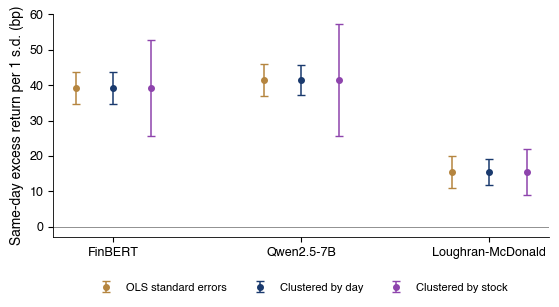

,b_bp,se_ols,se_day,se_tic,t_ols,t_day,t_tic,n,G_day,G_tic,r2
finbert|r0,39.228,2.309,2.271,6.869,16.988,17.271,5.711,18282.0,3434.0,16.0,0.016
finbert|r1,3.184,2.233,1.990,2.538,1.426,1.600,1.255,18282.0,3434.0,16.0,0.000
finbert|r2,-0.536,2.180,2.153,1.514,-0.246,-0.249,-0.354,18282.0,3434.0,16.0,0.000
lm|r0,15.474,2.325,1.813,3.291,6.657,8.534,4.702,18282.0,3434.0,16.0,0.002
lm|r1,-0.365,2.233,1.710,1.430,-0.164,-0.214,-0.255,18282.0,3434.0,16.0,0.000
lm|r2,-0.026,2.180,1.737,0.875,-0.012,-0.015,-0.029,18282.0,3434.0,16.0,0.000
qwen|r0,41.446,2.307,2.174,8.134,17.965,19.068,5.096,18282.0,3434.0,16.0,0.017
qwen|r1,3.695,2.233,1.984,3.014,1.655,1.862,1.226,18282.0,3434.0,16.0,0.000
qwen|r2,2.315,2.180,1.938,0.959,1.062,1.194,2.414,18282.0,3434.0,16.0,0.000


In [23]:
B5 = b_cluster(P)
fig_cluster(B5)
pd.DataFrame(B5).T.round(3)

### B6. Event study with the Loughran–McDonald tone [Proposed]

- Pre-event, day-0 and post-event excess returns for negative-tone and positive-tone stock-days: the daily LM tone is 0 on about half of the stock-days, so both tercile cut-offs are 0 and the groups are tone < 0 and tone > 0 (zeros dropped); FinBERT: bottom and top terciles. Model: B5.

In [ ]:
# Your code here


### B7. Does the model remember the market? [Solved]

- AUC of P('rise') for the monthly direction of the S&P 500, before and after the release of Qwen2.5; permutation p-value.
- Interpretation: what does this imply for backtests that use an LLM on past news?

In [25]:
print(json.dumps(jsonable(b_memory()), indent=1))

{
 "1.5B": {
  "pre": {
   "auc": 0.5745556367177989,
   "lo": 0.505968609182546,
   "hi": 0.6406150436017946,
   "n": 296,
   "n_up": 185,
   "mean_up": 0.3604982648648649,
   "mean_down": 0.2962801531531532
  },
  "post": {
   "auc": 0.7192307692307692,
   "lo": 0.4924213286713287,
   "hi": 0.9126984126984127,
   "n": 23,
   "n_up": 13,
   "mean_up": 0.7372707692307693,
   "mean_down": 0.6646426999999999
  }
 },
 "7B": {
  "pre": {
   "auc": 0.6700267835402971,
   "lo": 0.6056984737167468,
   "hi": 0.7349237007541021,
   "n": 296,
   "n_up": 185,
   "mean_up": 0.7316874594594595,
   "mean_down": 0.4336406036036035
  },
  "post": {
   "auc": 0.5307692307692308,
   "lo": 0.2833333333333333,
   "hi": 0.7833578431372548,
   "n": 23,
   "n_up": 13,
   "mean_up": 0.6006488461538462,
   "mean_down": 0.4712244
  }
 },
 "14B": {
  "pre": {
   "auc": 0.6872656440224008,
   "lo": 0.6221625099045155,
   "hi": 0.7525884330897763,
   "n": 296,
   "n_up": 185,
   "mean_up": 0.8101882378378379,
   "

### B8. Prompt sensitivity [Proposed]

- Accuracy of three prompt wordings for Qwen2.5-7B and 14B; McNemar test P1 vs P3; share of identical labels. Model: B1.

In [ ]:
# Your code here


In [ ]:
# Functions of Lecture 15, section Sentiment Scores Are Estimates
def net(d, tag):
    return d[f'{tag}_positive'].values - d[f'{tag}_negative'].values


def label_num(d, tag):
    P = d[[f'{tag}_{l}' for l in LABELS]].values
    return P.argmax(1) - 1


def attenuation():
    tw = load_csv('ch15_twitter_scores.csv')
    s = tw['label'].map(SIGN).values.astype(float)
    sc = {'lm': tw['LM_tone'].values, 'finbert': net(tw, 'finbert'), 'qwen': net(tw, 'qwen7B')}
    lab = {'lm': tone_label(tw['LM_tone'].values), 'finbert': label_num(tw, 'finbert'), 'qwen': label_num(tw, 'qwen7B')}
    lab['lm'] = pd.Series(lab['lm']).map(SIGN).values
    out = {'rho': {}, 'lam_label': {}, 'aigner_neg': {}}
    for c in sc:
        out['rho'][c] = float(np.corrcoef(s, sc[c])[0, 1])
        L = lab[c].astype(float)
        out['lam_label'][c] = float(np.cov(s, L)[0, 1] / np.var(L, ddof=1))
        # Aigner (1973): binary "negative news" variable, misclassification
        t, h = (s == -1), (L == -1)
        pi, p = t.mean(), h.mean()
        a1 = np.mean(~h[t])          # P(predicted non-negative | truly negative)
        a0 = np.mean(h[~t])          # P(predicted negative | truly non-negative)
        lam = pi * (1 - pi) * (1 - a0 - a1) / (p * (1 - p))
        out['aigner_neg'][c] = {'pi': float(pi), 'p': float(p), 'a0': float(a0), 'a1': float(a1), 'lam': float(lam),
                                'lam_direct': float(np.cov(t, h)[0, 1] / np.var(h, ddof=1))}
    VI['atten'] = out
    return out


def factor_iv(P):
    """One-factor model for the three daily scores and IV with one score as the instrument for another."""
    Z = {c: P[f'z_{c}'].values for c in ('lm', 'finbert', 'qwen')}
    C = np.corrcoef(np.vstack([Z['lm'], Z['finbert'], Z['qwen']]))
    r = {('lm', 'finbert'): C[0, 1], ('lm', 'qwen'): C[0, 2], ('finbert', 'qwen'): C[1, 2]}
    rr = lambda a, b: r[(a, b)] if (a, b) in r else r[(b, a)]    # noqa: E731
    lam = {}
    for c in Z:
        o = [x for x in Z if x != c]
        lam[c] = float(np.sqrt(rr(c, o[0]) * rr(c, o[1]) / rr(o[0], o[1])))
    days = P.index.get_level_values('day')
    codes, uniq = pd.factorize(days)
    y = P['r0'].values
    rng = np.random.default_rng(15)
    out = {'lam_factor': lam, 'corr': {f'{a}|{b}': float(v) for (a, b), v in r.items()}, 'iv': {}}
    B = 999
    Gs = len(uniq)
    # sums by day for the cluster (day) bootstrap
    def sums(v):
        return np.bincount(codes, weights=v, minlength=Gs)
    raw = {'n': np.ones_like(y), 'y': y}
    raw.update({f'z{c}': Z[c] for c in Z})
    raw.update({f'yz{c}': y * Z[c] for c in Z})
    raw.update({f'{a}{b}': Z[a] * Z[b] for a in Z for b in Z})
    base = {k: sums(v) for k, v in raw.items()}

    def iv_from(S, x, zi):
        n = S['n']
        mx, mz, my = S[f'z{x}'] / n, S[f'z{zi}'] / n, S['y'] / n
        return (S[f'yz{zi}'] / n - my * mz) / (S[f'{x}{zi}'] / n - mx * mz)
    pairs = [('qwen', 'finbert'), ('qwen', 'lm'), ('finbert', 'qwen'), ('finbert', 'lm')]
    tot = {k: v.sum() for k, v in base.items()}
    est = {f'{x}|{zi}': float(iv_from(tot, x, zi)) for x, zi in pairs}
    boots = {k: [] for k in est}
    for _ in range(B):
        w = np.bincount(rng.integers(0, Gs, Gs), minlength=Gs)
        Sb = {k: (v * w).sum() for k, v in base.items()}
        for x, zi in pairs:
            boots[f'{x}|{zi}'].append(iv_from(Sb, x, zi))
    for k in est:
        v = np.array(boots[k])
        out['iv'][k] = {'b_bp': 100 * est[k], 'se_bp': 100 * float(v.std(ddof=1)),
                        'lo_bp': 100 * float(np.quantile(v, 0.025)), 'hi_bp': 100 * float(np.quantile(v, 0.975))}
    for x in ('qwen', 'finbert'):
        o = 'finbert' if x == 'qwen' else 'qwen'
        d = np.array(boots[f'{x}|{o}']) - np.array(boots[f'{x}|lm'])
        dd = est[f'{x}|{o}'] - est[f'{x}|lm']
        out['iv'][f'diff_{x}'] = {'d_bp': 100 * dd, 'se_bp': 100 * float(d.std(ddof=1)),
                                  'z': float(dd / d.std(ddof=1))}
    VI['factor'] = out
    return out


def ppi_sim(ns=(100, 200, 400, 800), R=2000, seed=15):
    """PPI (Angelopoulos et al., 2023): labelled sample (n) and unlabelled sample (N - n) INDEPENDENT, predictor
    f fixed (trained on other data). The simulation treats the N validation headlines as the population: in each replication
    both samples are drawn independently, with replacement, so the variance Var(f)/(N - n) + Var(f - Y)/n is exact,
    and theta (the mean of the N labels) is the population mean."""
    tw = load_csv('ch15_twitter_scores.csv')
    y = tw['label'].map(SIGN).values.astype(float)
    theta = y.mean()
    F = {'finbert': net(tw, 'finbert'), 'qwen': net(tw, 'qwen7B')}
    N = len(y)
    rng = np.random.default_rng(seed)
    z = stats.norm.ppf(0.975)
    out = {'theta': float(theta), 'N': N, 'naive': {c: float(F[c].mean()) for c in F}, 'by_n': {}}
    for n in ns:
        res = {'classical': [], 'ppi_finbert': [], 'ppi_qwen': []}
        for _ in range(R):
            L, U = rng.integers(0, N, n), rng.integers(0, N, N - n)
            m, se = y[L].mean(), y[L].std(ddof=1) / np.sqrt(n)
            res['classical'].append((m, se))
            for c in F:
                f = F[c]
                rect = f[L] - y[L]
                est = f[U].mean() - rect.mean()
                se_p = np.sqrt(f[U].var(ddof=1) / len(U) + rect.var(ddof=1) / n)
                res[f'ppi_{c}'].append((est, se_p))
        r = {}
        for k, v in res.items():
            v = np.array(v)
            r[k] = {'cover': float(np.mean(np.abs(v[:, 0] - theta) <= z * v[:, 1])), 'width': float(np.mean(2 * z * v[:, 1])),
                    'bias': float(v[:, 0].mean() - theta)}
        out['by_n'][str(n)] = r
    # a concrete example with n = 200 (a random split of the headlines: n labelled, the rest unlabelled)
    idx = np.random.default_rng(1).permutation(N)
    L, U = idx[:200], idx[200:]
    ex = {'classical': (y[L].mean(), y[L].std(ddof=1) / np.sqrt(200))}
    for c in F:
        rect = F[c][L] - y[L]
        ex[c] = (F[c][U].mean() - rect.mean(), np.sqrt(F[c][U].var(ddof=1) / len(U) + rect.var(ddof=1) / 200),
                 rect.mean())
    out['example'] = {k: [float(x) for x in v] for k, v in ex.items()}
    # variance of the rectifier vs variance of the labels: the efficiency gain
    out['var_ratio'] = {c: float((F[c] - y).var() / y.var()) for c in F}
    VI['ppi'] = out
    return out


def fig_ppi():
    R = VI['ppi']
    ns = [int(n) for n in R['by_n']]
    fig, axes = plt.subplots(1, 2, figsize=(7.4, 2.9))
    lab = {'classical': 'Human labels only', 'ppi_finbert': 'PPI with FinBERT scores',
           'ppi_qwen': 'PPI with Qwen2.5-7B scores'}
    col = {'classical': MainBlue, 'ppi_finbert': Forest, 'ppi_qwen': IDAred}
    for k in lab:
        axes[0].plot(ns, [R['by_n'][str(n)][k]['width'] for n in ns], 'o-', color=col[k], label=lab[k], ms=4)
        axes[1].plot(ns, [100 * R['by_n'][str(n)][k]['cover'] for n in ns], 'o-', color=col[k], ms=4)
    axes[1].axhline(95, color=Gray, ls='--', lw=0.8)
    axes[0].set_xscale('log')
    axes[1].set_xscale('log')
    from matplotlib.ticker import NullFormatter, NullLocator
    for ax in axes:
        ax.set_xticks(ns)
        ax.set_xticklabels([str(n) for n in ns])
        ax.xaxis.set_minor_locator(NullLocator())
        ax.xaxis.set_minor_formatter(NullFormatter())
        ax.set_xlabel('Human-labelled headlines $n$')
    axes[0].set_ylabel('Mean width of the 95% CI')
    axes[1].set_ylabel('Coverage of the 95% CI (%)')
    axes[1].set_ylim(85, 100)
    h, l = axes[0].get_legend_handles_labels()
    fig.tight_layout()
    fig_legend_bottom(fig, h, l, ncol=3, y=0.0)
    save_fig('ch15_ppi')


def calib_stats(P, y, bins=10):
    conf = P.max(1)
    pred = P.argmax(1)
    hit = (pred == y).astype(float)
    edges = np.linspace(1 / 3, 1, bins + 1)
    k = np.clip(np.digitize(conf, edges[1:-1]), 0, bins - 1)
    ece = sum(np.abs(hit[k == b].mean() - conf[k == b].mean()) * np.mean(k == b) for b in range(bins) if np.any(k == b))
    Y = np.eye(3)[y]
    brier = float(np.mean(np.sum((P - Y) ** 2, 1)))
    ll = float(-np.mean(np.log(np.clip(P[np.arange(len(y)), y], 1e-12, 1))))
    rel = [(float(conf[k == b].mean()), float(hit[k == b].mean()), int(np.sum(k == b))) for b in range(bins) if np.any(k == b)]
    return {'ece': float(ece), 'brier': brier, 'logloss': ll, 'acc': float(hit.mean()), 'rel': rel}


def temp_scale(P, T):
    L = np.log(np.clip(P, 1e-12, 1)) / T
    L -= L.max(1, keepdims=True)
    E = np.exp(L)
    return E / E.sum(1, keepdims=True)


def calibration(seed=15):
    tw = load_csv('ch15_twitter_scores.csv')
    y = tw['label'].map({'negative': 0, 'neutral': 1, 'positive': 2}).values
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(y))
    A, B = idx[:len(y) // 2], idx[len(y) // 2:]
    out = {}
    for name, tag in (('finbert', 'finbert'), ('qwen7', 'qwen7B'), ('qwen14', 'qwen14B'),
                      ('qwen7_P2', 'qwen7B_P2'), ('qwen7_P3', 'qwen7B_P3')):
        P = tw[[f'{tag}_{l}' for l in LABELS]].values.astype(float)
        P = P / P.sum(1, keepdims=True)
        nll = lambda T: -np.mean(np.log(np.clip(temp_scale(P[A], T)[np.arange(len(A)), y[A]], 1e-12, 1)))  # noqa: E731
        T = float(minimize_scalar(nll, bounds=(0.05, 50), method='bounded').x)
        out[name] = {'raw': calib_stats(P[B], y[B]), 'T': T, 'scaled': calib_stats(temp_scale(P[B], T), y[B]),
                     'all': calib_stats(P, y)}
    VI['calib'] = out
    return out


def fig_calibration():
    R = VI['calib']
    fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.0), sharey=True)
    for ax, key, title in ((axes[0], 'raw', 'Raw probabilities'), (axes[1], 'scaled', 'After temperature scaling')):
        ax.plot([1 / 3, 1], [1 / 3, 1], color=Gray, ls='--', lw=0.8)
        for m, c, lab in (('finbert', MainBlue, 'FinBERT'), ('qwen7', IDAred, 'Qwen2.5-7B'),
                          ('qwen14', Orange, 'Qwen2.5-14B')):
            rel = np.array(R[m][key]['rel'])
            ax.scatter(rel[:, 0], rel[:, 1], s=8 + 60 * rel[:, 2] / rel[:, 2].max(), color=c, alpha=0.85,
                       label=f"{lab}, ECE {100 * R[m][key]['ece']:.1f}%" if key == 'raw' else lab, lw=0)
            ax.plot(rel[:, 0], rel[:, 1], color=c, lw=0.8)
        ax.set_title(title, fontsize=8.5, loc='left')
        ax.set_xlabel('Predicted probability of the chosen label')
        ax.set_xlim(0.3, 1.02)
    axes[0].set_ylabel('Share correct')
    h, l = axes[0].get_legend_handles_labels()
    fig.tight_layout()
    fig_legend_bottom(fig, h, l, ncol=3, y=0.0)
    save_fig('ch15_calibration')


def wcr_boot(y, x, cl, B=9999, seed=15):
    """Restricted wild cluster bootstrap (b = 0), Rademacher weights, t with CR1 clustered SE."""
    y, x = np.asarray(y, float), np.asarray(x, float)
    codes, uniq = pd.factorize(np.asarray(cl))
    G, n = len(uniq), len(y)
    xd = x - x.mean()
    Sxx = xd @ xd
    cr1 = G / (G - 1) * (n - 1) / (n - 2)

    def tstat(yy):
        b = xd @ yy / Sxx
        e = yy - yy.mean() - b * xd
        s = np.bincount(codes, weights=xd * e, minlength=G)
        return b / np.sqrt(cr1 * (s @ s) / Sxx ** 2)
    t0 = tstat(y)
    et = y - y.mean()                      # residuals of the restricted model
    Ag = np.bincount(codes, weights=xd * et, minlength=G)
    Bg = np.bincount(codes, weights=xd * xd, minlength=G)
    Cg = np.bincount(codes, weights=et, minlength=G)
    Dg = np.bincount(codes, weights=xd, minlength=G)
    rng = np.random.default_rng(seed)
    W = rng.choice([-1.0, 1.0], size=(B, G))
    b = W @ Ag / Sxx
    dm = W @ Cg / n                        # deviation of the mean of y*
    S = W * Ag[None, :] - dm[:, None] * Dg[None, :] - b[:, None] * Bg[None, :]
    t = b / np.sqrt(cr1 * np.sum(S ** 2, 1) / Sxx ** 2)
    return float(t0), float(np.mean(np.abs(t) >= abs(t0)))


def twoway_se(y, x, c1, c2):
    """Two-way clustered SE (Cameron, Gelbach & Miller, 2011): V1 + V2 - V12."""
    y, x = np.asarray(y, float), np.asarray(x, float)
    xd = x - x.mean()
    Sxx = xd @ xd
    b = xd @ y / Sxx
    e = y - y.mean() - b * xd
    u = xd * e

    def V(cl):
        codes = pd.factorize(np.asarray(cl))[0]
        s = np.bincount(codes, weights=u)
        G = len(s)
        return G / (G - 1) * (s @ s) / Sxx ** 2
    inter = pd.Series(list(zip(c1, c2))).astype(str).values
    v = V(c1) + V(c2) - V(inter)
    return float(b), float(np.sqrt(max(v, 0)))


def holm(p):
    p = np.asarray(p, float)
    m = len(p)
    o = np.argsort(p)
    adj = np.empty(m)
    run = 0
    for k, i in enumerate(o):
        run = max(run, (m - k) * p[i])
        adj[i] = min(1.0, run)
    return adj


def panel_inference(P, strat=None):
    days = P.index.get_level_values('day')
    tic = P.index.get_level_values('ticker')
    rows = {}
    for c in ('lm', 'finbert', 'qwen'):
        for h in ('r0', 'r1', 'r2'):
            y, x = P[h].values, P[f'z_{c}'].values
            t_tic, p_wcr = wcr_boot(y, x, tic)
            b, se2 = twoway_se(y, x, days, tic)
            rows[f'{c}|{h}'] = {'b_bp': 100 * b, 't_tic': t_tic, 'p_t15': float(2 * stats.t.sf(abs(t_tic), 15)),
                                'p_wcr': p_wcr, 't_2way': b / se2, 'p_2way': float(2 * stats.t.sf(abs(b / se2), 15))}
    keys = list(rows)
    adj = holm([rows[k]['p_wcr'] for k in keys])
    for k, a in zip(keys, adj):
        rows[k]['p_wcr_holm'] = float(a)
    # the d+2 strategies: Newey-West t, Normal p-value, Holm over 3 scores
    if strat is None:
        with open(os.path.join(HERE, 'ch15_results.json')) as f:
            strat = json.load(f)['news']['strat']
    st = strat
    ps = {c: float(2 * stats.norm.sf(abs(st[c]['t']))) for c in ('lm', 'finbert', 'qwen')}
    ha = holm(list(ps.values()))
    VI['panel'] = {'reg': rows, 'strat_p': ps, 'strat_holm': dict(zip(ps, map(float, ha)))}
    return VI['panel']


def event_inference(P, rets, col='finbert'):
    neg, pos = event_groups(P[col])
    sub = P[neg | pos].copy()
    sub['pos'] = pos[neg | pos].astype(float)
    sub['post'] = sub[['r2', 'rp3', 'rp4', 'rp5']].sum(1, min_count=4)
    sub['pre'] = sub[['rm5', 'rm4', 'rm3', 'rm2', 'rm1']].sum(1, min_count=5)
    out = {}
    for w in ('pre', 'r0', 'r1', 'post'):
        s = sub.dropna(subset=[w])
        r = cluster_ols(s[w].values, s['pos'].values, s.index.get_level_values('day'))
        out[w] = {'d': float(r['b']), 'lo': float(r['b'] - 1.96 * r['se_cl']), 'hi': float(r['b'] + 1.96 * r['se_cl']),
                  't': float(r['t_cl'])}
    # BMP: CAR standardised by the standard deviation of the excess return over the 250 days ending at -6
    ex = rets.drop(columns='SPY').sub(rets['SPY'], axis=0)
    sd = ex.rolling(250, min_periods=120).std().shift(6)
    sds = sd.stack()
    sds.index.names = ['day', 'ticker']
    sub = sub.join(sds.rename('sig'), how='left').dropna(subset=['sig', 'post'])
    sub['scar'] = sub['post'] / (sub['sig'] * np.sqrt(4))
    for grp, sel in (('pos', sub['pos'] == 1), ('neg', sub['pos'] == 0)):
        v = sub.loc[sel, 'scar'].values
        out[f'bmp_{grp}'] = {'mean_scar': float(v.mean()), 'z': float(v.mean() * np.sqrt(len(v)) / v.std(ddof=1)),
                             'n': int(len(v))}
    VI['event'] = out
    return out


def nw_t_mat(X, L):
    n = X.shape[1]
    mu = X.mean(1)
    U = X - mu[:, None]
    v = np.sum(U * U, 1) / n
    for l in range(1, L + 1):
        v += 2 * (1 - l / (L + 1)) * np.sum(U[:, l:] * U[:, :-l], 1) / n
    return mu / np.sqrt(v / n)


def portfolio(P, col, days, band, ret, lag):
    q = P[P[col].abs() > band]
    pos_day = pd.DatetimeIndex(days)
    idx = pos_day.get_indexer(q.index.get_level_values('day'))
    ok = (idx >= 0) & (idx + lag < len(pos_day))
    q = q[ok]
    x = pd.Series(np.sign(q[col].values) * q[ret].values, index=pos_day[idx[ok] + lag])
    return x.groupby(level=0).mean().reindex(pos_day).fillna(0.0)


def spec_curve(P, rets, B=2000, seed=15, block=10):
    """Joint null: Rademacher weights constant over blocks of `block` consecutive signal days (dependent wild
    bootstrap, Shao, 2010), the same for all specifications. Assumptions: under the null, the signed returns of each
    block are symmetric around 0 and the blocks are roughly independent; the dependence between
    specifications and the serial dependence within a block are preserved."""
    days = rets.index[rets.index >= P.index.get_level_values('day').min()]
    series = []
    meta = []
    for c in SCORES:
        for b in BANDS:
            for ret, lag in HOLD.items():
                x = portfolio(P.dropna(subset=[ret]), c, days, b, ret, lag)
                # indexed by the signal day (return day minus lag): the same sign flip for all
                s = pd.Series(x.values, index=pd.DatetimeIndex(days)).shift(-lag).reindex(days).fillna(0.0)
                series.append(s.values)
                meta.append({'score': c, 'band': b, 'day': lag})
    X = np.vstack(series)
    n = X.shape[1]
    L = int(np.floor(4 * (n / 100) ** (2 / 9)))
    t_obs = nw_t_mat(X, L)
    rng = np.random.default_rng(seed)
    cnt, med = [], []
    for _ in range(B):
        w = np.repeat(rng.choice([-1.0, 1.0], size=int(np.ceil(n / block))), block)[:n]
        tb = nw_t_mat(X * w[None, :], L)
        cnt.append(np.sum(tb > 1.96))
        med.append(np.median(tb))
    cnt, med = np.array(cnt), np.array(med)
    k_obs = int(np.sum(t_obs > 1.96))
    out = {'t': t_obs.tolist(), 'meta': meta, 'n_pos_sig': k_obs, 'median_t': float(np.median(t_obs)),
           'p_count': float(np.mean(cnt >= k_obs)), 'p_median': float(np.mean(med >= np.median(t_obs))),
           'null_q95_count': float(np.quantile(cnt, 0.95)), 'n_neg_sig': int(np.sum(t_obs < -1.96)), 'B': B,
           'block': block}
    VI['spec'] = out
    return out


def fig_spec_curve():
    R = VI['spec']
    t = np.array(R['t'])
    meta = R['meta']
    o = np.argsort(t)
    col = {'lm': Orange, 'finbert': MainBlue, 'qwen': IDAred}
    lab = {'lm': 'Loughran-McDonald', 'finbert': 'FinBERT', 'qwen': 'Qwen2.5-7B'}
    fig, ax = plt.subplots(figsize=(6.8, 2.9))
    for c in col:
        k = [j for j, i in enumerate(o) if meta[i]['score'] == c]
        ax.scatter(k, t[o][k], color=col[c], s=16, label=lab[c], zorder=3)
    ax.axhline(1.96, color=Gray, ls='--', lw=0.8)
    ax.axhline(-1.96, color=Gray, ls='--', lw=0.8)
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_xlabel('36 specifications, sorted by t (score x threshold x holding day)')
    ax.set_ylabel('Newey-West t, mean daily return')
    legend_outside_bottom(ax, ncol=3, y=-0.2)
    save_fig('ch15_spec_curve')


def delong_var(p, up):
    p, up = np.asarray(p, float), np.asarray(up, bool)
    X, Y = p[up], p[~up]
    psi = (X[:, None] > Y[None, :]).astype(float) + 0.5 * (X[:, None] == Y[None, :])
    V10, V01 = psi.mean(1), psi.mean(0)
    a = psi.mean()
    return float(a), float(V10.var(ddof=1) / len(X) + V01.var(ddof=1) / len(Y))


def auc_test():
    mm = load_csv('ch15_memory_monthly.csv', index_col=0, parse_dates=True)
    out = {}
    z80 = stats.norm.ppf(0.975) + stats.norm.ppf(0.80)
    for s in ('7B', '14B'):
        pre = mm.loc[:'2024-08-31']
        post = mm.loc['2024-10-01':]
        a1, v1 = delong_var(pre[f'qwen{s}'], pre['ret'] > 0)
        a2, v2 = delong_var(post[f'qwen{s}'], post['ret'] > 0)
        m, n = int((post['ret'] > 0).sum()), int((post['ret'] <= 0).sum())
        v0 = (m + n + 1) / (12 * m * n)       # variance of the AUC when AUC = 0.5 (Hanley & McNeil)
        z = (a1 - a2) / np.sqrt(v1 + v2)
        out[s] = {'auc_pre': a1, 'auc_post': a2, 'se_pre': np.sqrt(v1), 'se_post': np.sqrt(v2), 'z': float(z),
                  'p': float(2 * stats.norm.sf(abs(z))), 'mde': float(z80 * np.sqrt(v1 + v0)),
                  'se0_post': float(np.sqrt(v0)), 'n_up': m, 'n_down': n}
        # months needed after release to detect the fall to 0.5 with 80% power (same share of up months)
        share = m / (m + n)
        need = None
        for T in range(20, 2000):
            mu, nd = max(1, round(share * T)), max(1, T - round(share * T))
            if z80 * np.sqrt(v1 + (mu + nd + 1) / (12 * mu * nd)) <= a1 - 0.5:
                need = T
                break
        out[s]['months_needed'] = need
    VI['auc'] = out
    return out


def leakage_did(B=2000, seed=15):
    pb = load_csv('ch15_phrasebank_scores.csv')
    tw = load_csv('ch15_twitter_scores.csv')
    hit = {}
    for name, d in (('pb', pb), ('tw', tw)):
        pr = predictions(d)
        hit[name] = {m: (pr[m] == d['label'].values).astype(float) for m in ('FinBERT', 'Qwen 7B')}
    did = lambda a, b: (a['FinBERT'].mean() - b['FinBERT'].mean()) - (a['Qwen 7B'].mean() - b['Qwen 7B'].mean())  # noqa
    est = did(hit['pb'], hit['tw'])
    rng = np.random.default_rng(seed)
    v = []
    for _ in range(B):
        i = rng.integers(0, len(pb), len(pb))
        j = rng.integers(0, len(tw), len(tw))
        v.append(did({k: x[i] for k, x in hit['pb'].items()}, {k: x[j] for k, x in hit['tw'].items()}))
    VI['did'] = {'did': float(est), 'lo': float(np.quantile(v, 0.025)), 'hi': float(np.quantile(v, 0.975)),
                 'drop_fb': float(hit['pb']['FinBERT'].mean() - hit['tw']['FinBERT'].mean()),
                 'drop_q7': float(hit['pb']['Qwen 7B'].mean() - hit['tw']['Qwen 7B'].mean())}
    return VI['did']


def timing():
    """Time per headline: one pass for each prompt; median of the three prompts."""
    t = load_csv('ch15_llm_time.csv', index_col=0)['sec_per_text']
    out = {}
    for s in ('0.5B', '1.5B', '3B', '7B', '14B'):
        v = t[[k for k in t.index if k.startswith(f'time_qwen{s}')]].values
        out[s] = {'median': float(np.median(v)), 'min': float(v.min()), 'max': float(v.max()), 'k': int(len(v))}
    VI['time'] = out
    return out


from scipy.optimize import minimize_scalar
VI = {}
SIGN = {'negative': -1, 'neutral': 0, 'positive': 1}
SCORES, BANDS, HOLD = ('lm', 'finbert', 'qwen'), (0.0, 0.25, 0.5), {'r2': 2, 'rp3': 3, 'rp4': 4, 'rp5': 5}

### B9. Prediction-powered inference with a few human labels [Solved]

- Mean human net tone of the headline population (the Twitter validation headlines act as the population) from $n$ labels plus model scores; labelled and unlabelled samples drawn independently with replacement, 2 000 replications; the model is fixed (not trained on these headlines).
- Interpretation: why is the plain model mean not an estimate of the true mean?

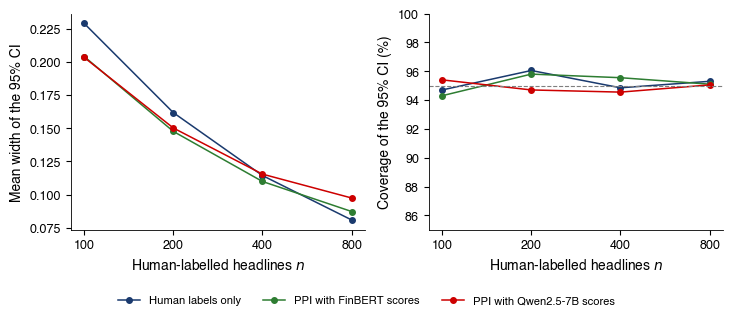

{
 "theta": 0.05360134003350084,
 "N": 2388,
 "naive": {
  "finbert": -0.014069440954773858,
  "qwen": 0.10134089782244556
 },
 "by_n": {
  "100": {
   "classical": {
    "cover": 0.947,
    "width": 0.2289035536048906,
    "bias": 0.0033836599664991626
   },
   "ppi_finbert": {
    "cover": 0.943,
    "width": 0.20397408107234735,
    "bias": 0.0010359557288942695
   },
   "ppi_qwen": {
    "cover": 0.954,
    "width": 0.20329242805233846,
    "bias": -0.00014937447124559883
   }
  },
  "200": {
   "classical": {
    "cover": 0.9605,
    "width": 0.16173102066510142,
    "bias": 3.865996649916187e-05
   },
   "ppi_finbert": {
    "cover": 0.958,
    "width": 0.14760912959382178,
    "bias": 6.006247967558359e-05
   },
   "ppi_qwen": {
    "cover": 0.947,
    "width": 0.15017260295456566,
    "bias": 0.0008121233727423002
   }
  },
  "400": {
   "classical": {
    "cover": 0.9485,
    "width": 0.11437569848103583,
    "bias": 0.00022365996649916647
   },
   "ppi_finbert": {
    "cover"

In [28]:
R9 = ppi_sim()
fig_ppi()
print(json.dumps(jsonable(R9), indent=1))

### B10. Wild cluster bootstrap with 16 stocks [Proposed]

- Nine regressions of B5 clustered by stock: wild cluster bootstrap with the null imposed, two-way clustering, Holm. Model: B5.

In [ ]:
# Your code here


### B11. Specification curve for the sentiment strategy [Proposed]

- 36 strategies (score × threshold × return day d+2..d+5, each a one-day position opened at the previous close); joint null by sign flips in blocks of 10 signal days (dependent wild bootstrap, Shao, 2010), valid if signed returns are symmetric under the null and blocks roughly independent. Model: B7.

In [ ]:
# Your code here


## Part C — does FinBERT sentiment on headlines predict the d+2 excess return after costs? [Proposed]

- Daily strategy: at the close of d+1, sign of the day-d score in each stock with news, hedged with SPY, closed at the close of d+2.
- Newey–West $t$, block-bootstrap interval, Sharpe ratio before and after costs, break-even cost, strong-news filter.

In [ ]:
# Your code here
